<a href="https://colab.research.google.com/github/rodrigoalves022/Topicos/blob/Projetos/analise_gap_win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do Mini Índice WIN com foco em Gap

- gap de abertura;
- comportamento intraday após o gap;
- influência da janela de pré-close do dia anterior;
- criação de tabelas derivadas para análise estatística e machine learning.

-

- Qual a frequência de gap positivo e negativo?
- Quando o gap costuma fechar?
- O comportamento dos últimos 15 minutos do pregão anterior ajuda a prever o dia seguinte?
- Quais features fazem sentido para modelos supervisionados sem lookahead bias?


## 1. Configuração do estudo

Nesta etapa definimos os parâmetros principais do notebook: caminho do arquivo, tamanho da janela de pré-close, janelas de fill, bins de gap e horizontes de retorno.

Leitura rápida dos parâmetros:

- `JANELA_ATR = 14`: usa os últimos 14 dias para calcular o ATR médio.
- `JANELAS_FORWARD = [5, 15, 30]`: mede o retorno do preço 5, 15 e 30 minutos após a abertura.
- `JANELAS_FILL = [5, 10, 20, 30]`: mede se o gap fechou até 5, 10, 20 ou 30 minutos após a abertura.
- `ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]`: cria alvos de fill parcial em 30%, 50%, 70% e 100% do gap.
- `BINS_GAP = [...]`: separa os gaps em faixas para resumir estatísticas.
- `MINIMO_LINHAS_TREINO = 150`: evita treinar modelo com pouca amostra.
- `np.inf`: significa infinito. Aqui ele serve para criar uma faixa sem limite, por exemplo `200 até infinito`.


In [26]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
plt.style.use('ggplot')

In [27]:
# ─── CAMINHO DOS DADOS ───
CAMINHO_DADOS = 'https://raw.githubusercontent.com/rodrigoalves022/Topicos/Projetos/WIN%24N_M1.csv'

# CAMINHO_DADOS = Path('WIN$N_M1.csv')

# Pasta onde as bases derivadas serão salvas.
PASTA_SAIDA = Path('outputs_gap_win')
PASTA_SAIDA.mkdir(exist_ok=True)

# Quantidade de minutos usados para resumir o final do pregão anterior.
MINUTOS_PRECLOSE = 15

# Janela do ATR diário. ATR é uma medida média de amplitude/volatilidade.
JANELA_ATR = 14

# Retornos futuros medidos a partir da abertura do dia.
JANELAS_FORWARD = [5, 15, 30]

# Janelas máximas para considerar que o gap fechou em um trade intraday.
JANELAS_FILL = [5, 10, 15, 20, 30]

# Percentuais do gap que serão usados como alvos parciais de fill.
ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]

# Faixas de gap em pontos. np.inf significa infinito.
BINS_GAP = [-np.inf, -200, -150, -100, -50, 0, 50, 100, 150, 200, np.inf]

# Quantidade mínima de linhas para aceitar o treino do modelo.
MINIMO_LINHAS_TREINO = 150

print(f'Arquivo/Url configurado: {CAMINHO_DADOS.resolve() if isinstance(CAMINHO_DADOS, Path) else CAMINHO_DADOS}')
print(f'Pasta de saída: {PASTA_SAIDA.resolve()}')


Arquivo/Url configurado: https://raw.githubusercontent.com/rodrigoalves022/Topicos/Projetos/WIN%24N_M1.csv
Pasta de saída: /content/outputs_gap_win


## 2. Importação e padronização da base intraday

O arquivo veio no formato exportado de plataforma de mercado, com colunas entre `<>` e separação por tabulação. Aqui nós:

- lemos a base corretamente com `sep='\t'`;
- renomeamos as colunas para nomes limpos;
- criamos o `datetime`;
- ordenamos temporalmente;
- validamos duplicidades e dados faltantes.


In [ ]:
# O arquivo está separado por tabulação. Por isso usamos sep='\t'.
dados_brutos = pd.read_csv(CAMINHO_DADOS, sep='	')
dados_brutos.columns = [coluna.strip('<>').lower() for coluna in dados_brutos.columns]

# Padronizamos alguns nomes para deixar as colunas mais legíveis.
mapa_renomeacao = {
    'tickvol': 'tick_volume',
    'vol': 'volume',
    'spread': 'spread'
}
dados_brutos = dados_brutos.rename(columns=mapa_renomeacao)

base_intraday = dados_brutos.copy()

# Junta data e hora em uma única coluna temporal.
base_intraday['datetime'] = pd.to_datetime(
    base_intraday['date'] + ' ' + base_intraday['time'],
    format='%Y.%m.%d %H:%M:%S'
)
base_intraday = base_intraday.sort_values('datetime').reset_index(drop=True)

colunas_preco = ['open', 'high', 'low', 'close']
colunas_auxiliares = ['tick_volume', 'volume', 'spread']

# Garante que as colunas numéricas realmente sejam tratadas como números.
for coluna in colunas_preco + colunas_auxiliares:
    base_intraday[coluna] = pd.to_numeric(base_intraday[coluna], errors='coerce')

# session_date representa o dia de pregão sem a parte do horário.
base_intraday['session_date'] = base_intraday['datetime'].dt.normalize()
base_intraday['clock_time'] = base_intraday['datetime'].dt.time
base_intraday['minute'] = base_intraday['datetime'].dt.hour * 60 + base_intraday['datetime'].dt.minute

print('Shape intraday:', base_intraday.shape)
print('Período:', base_intraday['datetime'].min(), '->', base_intraday['datetime'].max())
print('Duplicidades de datetime:', base_intraday['datetime'].duplicated().sum())
print('Valores nulos principais:')
print(base_intraday[colunas_preco + colunas_auxiliares].isna().sum())

base_intraday.head()


## 3. Sanidade temporal do pregão

Nem todo dia tem o mesmo número de barras. Isso pode ocorrer por horário estendido, mudanças de sessão, início parcial da amostra ou dias especiais. Antes de modelar qualquer coisa, conferimos a estrutura diária para evitar assumir horários fixos incorretos.


In [ ]:
# Esta tabela ajuda a entender a estrutura de cada sessão.
agenda_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        primeira_barra=('datetime', 'min'),
        ultima_barra=('datetime', 'max'),
        quantidade_barras=('datetime', 'size')
    )
    .assign(
        horario_abertura=lambda df: df['primeira_barra'].dt.strftime('%H:%M:%S'),
        horario_fechamento=lambda df: df['ultima_barra'].dt.strftime('%H:%M:%S')
    )
)

print('Quantidade de dias:', len(agenda_diaria))
print()
print('Distribuição de barras por dia:')
print(agenda_diaria['quantidade_barras'].describe())
print()
print('Horários de fechamento mais comuns:')
print(agenda_diaria['horario_fechamento'].value_counts().head(10))

agenda_diaria.head()


## 4. Funções auxiliares

As próximas análises exigem medidas que não vêm prontas do CSV, como tempo até o fill, fill por janela de tempo, retornos futuros após a abertura e métricas de excursão (`MFE` e `MAE`).

Leitura em português:

- `MFE` = excursão favorável máxima;
- `MAE` = excursão adversa máxima;
- retornos "forward" = retornos medidos alguns minutos depois da abertura;
- fill temporal = verificar se o gap fechou dentro de uma janela, como 5, 10, 20 ou 30 minutos.

Essas funções existem para evitar repetição de código e deixar a lógica mais fácil de revisar.


In [ ]:
def primeiro_horario_que_bate(day_frame, condicao):
    """Retorna o primeiro horário em que a condição foi satisfeita."""
    acertos = day_frame.loc[condicao(day_frame)]
    if acertos.empty:
        return pd.NaT
    return acertos['datetime'].iloc[0]


def minutos_entre(inicio, fim):
    """Converte diferença de tempo para minutos."""
    if pd.isna(inicio) or pd.isna(fim):
        return np.nan
    return (fim - inicio).total_seconds() / 60.0


def calcular_retornos_forward(day_frame, preco_entrada, janelas):
    """Mede o retorno após N minutos a partir do preço de entrada."""
    resultados = {}
    fechamentos = day_frame['close'].reset_index(drop=True)
    for janela in janelas:
        if len(fechamentos) > janela:
            resultados[f'ret_{janela}m_from_open'] = fechamentos.iloc[janela] / preco_entrada - 1
        else:
            resultados[f'ret_{janela}m_from_open'] = np.nan
    return resultados


def lado_do_fill(gap_em_pontos):
    """Informa se o preço precisa subir ou cair para preencher o gap."""
    if gap_em_pontos > 0:
        return 'down_to_prev_close'
    if gap_em_pontos < 0:
        return 'up_to_prev_close'
    return 'flat'


def calcular_fills_temporais(dados_dia, fechamento_anterior, gap_em_pontos, janelas_fill):
    """Calcula se houve fill total dentro de cada janela após a abertura."""
    resultados = {}
    inicio = dados_dia['datetime'].iloc[0]

    for minutos in janelas_fill:
        janela = dados_dia.iloc[: min(len(dados_dia), minutos + 1)].copy()

        if gap_em_pontos > 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['low'] <= fechamento_anterior)
        elif gap_em_pontos < 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['high'] >= fechamento_anterior)
        else:
            horario_fill = inicio

        resultados[f'fill_ate_{minutos}m'] = int(pd.notna(horario_fill))
        resultados[f'tempo_fill_ate_{minutos}m'] = minutos_entre(inicio, horario_fill)

    return resultados


## 5. Base diária

Aqui transformamos a base de 1 minuto em uma visão diária com abertura (`open`), máxima (`high`), mínima (`low`) e fechamento (`close`), além de volume agregado e métricas de retorno e volatilidade.

Fórmulas principais desta etapa:

- amplitude do dia = `high - low`
- retorno fechamento contra fechamento anterior = `close_t / close_(t-1) - 1`
- retorno abertura até fechamento = `close_t / open_t - 1`
- `TR` = maior valor entre amplitude do dia, distância da máxima ao fechamento anterior e distância da mínima ao fechamento anterior
- `ATR_14` = média móvel de 14 períodos do `TR`

O objetivo desta base é resumir cada pregão em uma única linha.


In [ ]:
# A base diaria resume cada sessão em uma Única linha.
base_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        tick_volume=('tick_volume', 'sum'),
        volume=('volume', 'sum'),
        spread_mean=('spread', 'mean'),
        first_bar=('datetime', 'min'),
        last_bar=('datetime', 'max'),
        n_bars=('datetime', 'size')
    )
    .sort_index()
)

# Medidas básicas do dia.
base_diaria['range'] = base_diaria['high'] - base_diaria['low']
base_diaria['return_close_to_close'] = base_diaria['close'].pct_change()
base_diaria['return_open_to_close'] = base_diaria['close'] / base_diaria['open'] - 1
base_diaria['prev_close'] = base_diaria['close'].shift(1)
base_diaria['prev_high'] = base_diaria['high'].shift(1)
base_diaria['prev_low'] = base_diaria['low'].shift(1)
base_diaria['prev_range'] = base_diaria['range'].shift(1)

# True Range: maior deslocamento relevante do dia.
base_diaria['tr'] = np.maximum.reduce([
    base_diaria['high'] - base_diaria['low'],
    (base_diaria['high'] - base_diaria['prev_close']).abs(),
    (base_diaria['low'] - base_diaria['prev_close']).abs()
])

# ATR: média do true range ao longo de N pregões.
base_diaria['atr_14'] = base_diaria['tr'].rolling(JANELA_ATR).mean()

# Classificação simples da cor do dia.
base_diaria['day_direction'] = np.where(base_diaria['close'] > base_diaria['open'], 'green', np.where(base_diaria['close'] < base_diaria['open'], 'red', 'doji'))

base_diaria.head()


## 6. Base de gap

Agora criamos a base principal do estudo. Cada linha representa um dia comparado ao fechamento do dia anterior.

Principais fórmulas:

- gap em pontos = `open_t - close_(t-1)`
- gap percentual = `(open_t - close_(t-1)) / close_(t-1)`
- gap normalizado pelo ATR = `gap / ATR`

Nesta versão, o fill principal deixa de ser "em qualquer momento do dia" e passa a ser analisado por janelas após a abertura:

- fill até 5 minutos;
- fill até 10 minutos;
- fill até 20 minutos;
- fill até 30 minutos.

Isso deixa o estudo mais alinhado com day trade.


In [13]:
linhas_gap = []
datas_pregao = base_diaria.index.tolist()

# Cada linha final representa o dia atual em relação ao fechamento do dia anterior.
for indice, data_pregao in enumerate(datas_pregao):
    if indice == 0:
        continue

    dados_dia = base_intraday.loc[base_intraday['session_date'] == data_pregao].copy()
    data_anterior = datas_pregao[indice - 1]
    fechamento_anterior = base_diaria.loc[data_anterior, 'close']
    abertura_atual = base_diaria.loc[data_pregao, 'open']
    maxima_atual = base_diaria.loc[data_pregao, 'high']
    minima_atual = base_diaria.loc[data_pregao, 'low']
    fechamento_atual = base_diaria.loc[data_pregao, 'close']

    gap_absoluto = abertura_atual - fechamento_anterior
    gap_percentual = gap_absoluto / fechamento_anterior if fechamento_anterior else np.nan
    atr_do_dia = base_diaria.loc[data_pregao, 'atr_14']
    gap_sobre_atr = gap_absoluto / atr_do_dia if pd.notna(atr_do_dia) and atr_do_dia != 0 else np.nan

    gap_positivo = gap_absoluto > 0
    gap_negativo = gap_absoluto < 0

    # Mantemos o fill no dia inteiro apenas como referência secundária.
    houve_fill_no_dia = (
        (gap_positivo and minima_atual <= fechamento_anterior) or
        (gap_negativo and maxima_atual >= fechamento_anterior) or
        (gap_absoluto == 0)
    )

    horario_fill_no_dia = pd.NaT
    if gap_positivo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['low'] <= fechamento_anterior)
    elif gap_negativo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['high'] >= fechamento_anterior)
    elif gap_absoluto == 0:
        horario_fill_no_dia = dados_dia['datetime'].iloc[0]

    linha = {
        'session_date': data_pregao,
        'prev_date': data_anterior,
        'prev_close': fechamento_anterior,
        'open': abertura_atual,
        'high': maxima_atual,
        'low': minima_atual,
        'close': fechamento_atual,
        'gap_abs': gap_absoluto,
        'gap_pct': gap_percentual,
        'gap_atr': gap_sobre_atr,
        'gap_direction': 'positive' if gap_positivo else 'negative' if gap_negativo else 'flat',
        'gap_side_to_fill': lado_do_fill(gap_absoluto),
        'gap_fill_no_dia': int(houve_fill_no_dia),
        'time_to_fill_no_dia_min': minutos_entre(dados_dia['datetime'].iloc[0], horario_fill_no_dia),
        'close_vs_open_ret': fechamento_atual / abertura_atual - 1,
        'close_vs_prev_close_ret': fechamento_atual / fechamento_anterior - 1,
        'day_green': int(fechamento_atual > abertura_atual),
        'day_red': int(fechamento_atual < abertura_atual),
        'mfe_buy_from_open': maxima_atual - abertura_atual,
        'mae_buy_from_open': abertura_atual - minima_atual,
        'mfe_sell_from_open': abertura_atual - minima_atual,
        'mae_sell_from_open': maxima_atual - abertura_atual,
    }

    linha.update(calcular_retornos_forward(dados_dia, abertura_atual, JANELAS_FORWARD))
    linha.update(calcular_fills_temporais(dados_dia, fechamento_anterior, gap_absoluto, JANELAS_FILL))

    # Fills parciais no dia inteiro continuam disponíveis como referência complementar.
    tamanho_gap = abs(gap_absoluto)
    for alpha in ALVOS_ALPHA:
        alvo_fill = alpha * tamanho_gap
        if gap_positivo:
            nivel = abertura_atual - alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['low'] <= lvl)
            bateu_alvo = int(minima_atual <= nivel)
        elif gap_negativo:
            nivel = abertura_atual + alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['high'] >= lvl)
            bateu_alvo = int(maxima_atual >= nivel)
        else:
            nivel = abertura_atual
            horario_alvo = dados_dia['datetime'].iloc[0]
            bateu_alvo = 1

        linha[f'fill_{int(alpha * 100)}pct_no_dia'] = bateu_alvo
        linha[f'fill_{int(alpha * 100)}pct_no_dia_tempo_min'] = minutos_entre(dados_dia['datetime'].iloc[0], horario_alvo)
        linha[f'fill_{int(alpha * 100)}pct_no_dia_nivel'] = nivel

    linhas_gap.append(linha)

base_gap = pd.DataFrame(linhas_gap).set_index('session_date').join(
    base_diaria[['range', 'atr_14', 'tick_volume', 'volume', 'n_bars']],
    how='left'
)

base_gap['gap_bin'] = pd.cut(base_gap['gap_abs'], bins=BINS_GAP)
base_gap['abs_gap_bin'] = pd.cut(base_gap['gap_abs'].abs(), bins=[0, 50, 100, 150, 200, np.inf], include_lowest=True)

base_gap.head()


,prev_date,prev_close,open,high,low,close,gap_abs,gap_pct,gap_atr,gap_direction,gap_side_to_fill,gap_fill_no_dia,time_to_fill_no_dia_min,close_vs_open_ret,close_vs_prev_close_ret,day_green,day_red,mfe_buy_from_open,mae_buy_from_open,mfe_sell_from_open,mae_sell_from_open,ret_5m_from_open,ret_15m_from_open,ret_30m_from_open,fill_ate_5m,tempo_fill_ate_5m,fill_ate_10m,tempo_fill_ate_10m,fill_ate_15m,tempo_fill_ate_15m,fill_ate_20m,tempo_fill_ate_20m,fill_ate_30m,tempo_fill_ate_30m,fill_30pct_no_dia,fill_30pct_no_dia_tempo_min,fill_30pct_no_dia_nivel,fill_50pct_no_dia,fill_50pct_no_dia_tempo_min,fill_50pct_no_dia_nivel,fill_70pct_no_dia,fill_70pct_no_dia_tempo_min,fill_70pct_no_dia_nivel,fill_100pct_no_dia,fill_100pct_no_dia_tempo_min,fill_100pct_no_dia_nivel,range,atr_14,tick_volume,volume,n_bars,gap_bin,abs_gap_bin
session_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-16,2020-10-15,99045,99340,99435,98280,98700,295,0.002978,NaN,positive,down_to_prev_close,1,11.0,-0.006443,-0.003483,0,1,95,1060,1060,95,-0.000755,-0.003624,-0.002819,0,NaN,0,NaN,1,11.0,1,11.0,1,11.0,1,4.0,99251.5,1,11.0,99192.5,1,11.0,99133.5,1,11.0,99045.0,1155,NaN,3214746,12868460,535,"(200.0, inf]","(200.0, inf]"
2020-10-19,2020-10-16,98700,99150,100170,98570,98940,450,0.004559,NaN,positive,down_to_prev_close,1,396.0,-0.002118,0.002432,0,1,1020,580,580,1020,-0.001311,-0.000151,-0.000050,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,4.0,99015.0,1,61.0,98925.0,1,395.0,98835.0,1,396.0,98700.0,1600,NaN,3194968,12871081,535,"(200.0, inf]","(200.0, inf]"
2020-10-20,2020-10-19,98940,99200,100970,99120,100930,260,0.002628,NaN,positive,down_to_prev_close,0,NaN,0.017440,0.020113,1,0,1770,80,80,1770,0.002671,0.002167,0.002268,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,99122.0,0,NaN,99070.0,0,NaN,99018.0,0,NaN,98940.0,1850,NaN,3230176,12894073,535,"(200.0, inf]","(200.0, inf]"
2020-10-21,2020-10-20,100930,100500,101875,100280,100710,-430,-0.004260,NaN,negative,up_to_prev_close,1,71.0,0.002090,-0.002180,1,0,1375,220,220,1375,0.001144,0.001940,0.001741,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,100629.0,1,1.0,100715.0,1,1.0,100801.0,1,71.0,100930.0,1595,NaN,3480858,13984220,535,"(-inf, -200.0]","(200.0, inf]"
2020-10-22,2020-10-21,100710,100660,102445,100565,102375,-50,-0.000496,NaN,negative,up_to_prev_close,1,3.0,0.017038,0.016533,1,0,1785,95,95,1785,0.002384,0.001540,0.001739,1,3.0,1,3.0,1,3.0,1,3.0,1,3.0,1,2.0,100675.0,1,2.0,100685.0,1,2.0,100695.0,1,3.0,100710.0,1880,NaN,3161866,13173842,535,"(-100.0, -50.0]","(-0.001, 50.0]"


## 7. Tabelas de apresentação do gap

Nesta seção construímos as tabelas principais para análise visual e apresentação dos gaps.

São geradas:

- **Contagem rápida**: total de gaps, quantos fecharam, taxa de fechamento.
- **Tabela geral dia a dia**: cada linha é um dia com fechamento anterior, abertura, gap, amplitude, se fechou, tempo, picos, etc.
- **Tabela resumo gap de alta**: agrupada por faixa de pontos com taxas de fechamento, curtose, assimetria.
- **Tabela resumo gap de baixa**: mesma estrutura, apenas para gaps negativos.

As faixas são geradas dinamicamente a partir do parâmetro `PASSO_FAIXA_PONTOS`.
Se o valor for 50, as faixas serão 0–50, 51–100, 101–150, etc.
Se for 100, as faixas serão 0–100, 101–200, etc.

In [14]:
# ── Funções auxiliares para tabelas de apresentação ──

DIAS_SEMANA_PT = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}


def classificar_faixas_modulo(gap_pts, passo_faixa_pontos=50):
    """Gera faixas dinâmicas de acordo com o passo informado."""
    modulo = pd.Series(gap_pts).abs().astype(float)
    topo = int(np.ceil(modulo.max() / passo_faixa_pontos) * passo_faixa_pontos) if len(modulo.dropna()) else passo_faixa_pontos
    topo = max(topo, passo_faixa_pontos)
    bins = np.arange(0, topo + passo_faixa_pontos, passo_faixa_pontos, dtype=float)
    bins = np.insert(bins, 0, -0.001)
    bins = np.unique(bins)
    return pd.cut(modulo, bins=bins, include_lowest=True)


def primeiro_movimento_fechamento_gap(dados_dia, direcao_gap, abertura, deslocamento_minimo=5):
    """Retorna o primeiro horário em que o preço se moveu na direção do fechamento do gap."""
    if direcao_gap == 'positive':
        candidatos = dados_dia.loc[dados_dia['low'] <= abertura - deslocamento_minimo, 'datetime']
    elif direcao_gap == 'negative':
        candidatos = dados_dia.loc[dados_dia['high'] >= abertura + deslocamento_minimo, 'datetime']
    else:
        return pd.NaT
    return candidatos.iloc[0] if not candidatos.empty else pd.NaT


def medir_picos_gap(dados_dia, abertura, direcao_gap, fechamento_anterior, deslocamento_minimo=5):
    """Calcula métricas de pico (máximo e mínimo), tempos e amplitudes do dia."""
    dados_dia = dados_dia.sort_values('datetime').reset_index(drop=True)
    inicio = dados_dia['datetime'].iloc[0]

    idx_max = int(dados_dia['high'].idxmax())
    idx_min = int(dados_dia['low'].idxmin())

    preco_max = float(dados_dia.loc[idx_max, 'high'])
    preco_min = float(dados_dia.loc[idx_min, 'low'])

    tempo_max = minutos_entre(inicio, dados_dia.loc[idx_max, 'datetime'])
    tempo_min = minutos_entre(inicio, dados_dia.loc[idx_min, 'datetime'])

    amp_max = preco_max - abertura
    amp_min = abertura - preco_min

    if direcao_gap == 'positive':
        pico_contra, tempo_contra = amp_min, tempo_min
        pico_favor, tempo_favor = amp_max, tempo_max
    elif direcao_gap == 'negative':
        pico_contra, tempo_contra = amp_max, tempo_max
        pico_favor, tempo_favor = amp_min, tempo_min
    else:
        pico_contra, tempo_contra = max(amp_max, amp_min), min(tempo_max, tempo_min)
        pico_favor, tempo_favor = np.nan, np.nan

    horario_inicio_fechamento = primeiro_movimento_fechamento_gap(
        dados_dia=dados_dia,
        direcao_gap=direcao_gap,
        abertura=abertura,
        deslocamento_minimo=deslocamento_minimo,
    )

    return {
        'tempo_ate_pico_max_min': tempo_max,
        'tempo_ate_pico_min_min': tempo_min,
        'duracao_entre_picos_min': abs(tempo_max - tempo_min),
        'pico_contra_gap_pts': pico_contra,
        'tempo_pico_contra_gap_min': tempo_contra,
        'pico_favor_gap_pts': pico_favor,
        'tempo_pico_favor_gap_min': tempo_favor,
        'tempo_inicio_fechamento_gap_min': minutos_entre(inicio, horario_inicio_fechamento),
        'dist_pico_max_ao_fechamento_anterior_pts': preco_max - fechamento_anterior,
        'dist_pico_min_ao_fechamento_anterior_pts': preco_min - fechamento_anterior,
    }


def gerar_tabelas_gap_apresentacao(base_gap_origem, base_intraday_origem,
                                    passo_faixa_pontos=50,
                                    deslocamento_minimo_inicio=5,
                                    limiar_sem_gap=20,
                                    limiar_overshoot=120):
    """Gera tabelas de apresentação com nomes legíveis em português."""

    # ── Calcular métricas de pico para cada dia ──
    linhas_metricas = []
    for _, linha in base_gap_origem.reset_index().iterrows():
        dados_dia = (
            base_intraday_origem
            .loc[base_intraday_origem['session_date'] == linha['session_date']]
            .sort_values('datetime')
            .reset_index(drop=True)
        )
        if dados_dia.empty:
            continue
        metricas = medir_picos_gap(
            dados_dia=dados_dia,
            abertura=float(linha['open']),
            direcao_gap=linha['gap_direction'],
            fechamento_anterior=float(linha['prev_close']),
            deslocamento_minimo=deslocamento_minimo_inicio,
        )
        linhas_metricas.append({'session_date': linha['session_date']} | metricas)

    base_metricas = pd.DataFrame(linhas_metricas)
    base = base_gap_origem.reset_index().merge(base_metricas, on='session_date', how='left')

    # Fill 60m derivado caso não exista.
    if 'fill_ate_60m' not in base.columns:
        base['fill_ate_60m'] = np.where(
            base['time_to_fill_no_dia_min'].notna() & (base['time_to_fill_no_dia_min'] <= 60),
            1, 0,
        )

    # Colunas auxiliares de apresentação.
    base['direcao_gap'] = base['gap_direction'].map({
        'positive': 'Gap de Alta', 'negative': 'Gap de Baixa', 'flat': 'Sem Gap'
    })
    base['gap_modulo_pts'] = base['gap_abs'].abs()
    base['faixa_gap_modulo_pts'] = classificar_faixas_modulo(base['gap_abs'], passo_faixa_pontos)
    base['dia_da_semana'] = pd.to_datetime(base['session_date']).dt.day_name().map(DIAS_SEMANA_PT)
    base['amplitude_dia'] = base['high'] - base['low']

    # Alias das colunas de fill.
    for janela in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{janela}m'
        if col in base.columns:
            base[f'fechamento_gap_ate_{janela}m'] = base[col]
    base['fechamento_gap_ate_60m'] = base['fill_ate_60m']
    base['fechamento_gap_no_dia'] = base['gap_fill_no_dia']

    # ── Tabela dia a dia ──
    colunas_tabela = [
        'session_date', 'dia_da_semana', 'direcao_gap',
        'prev_close', 'open', 'high', 'low', 'close',
        'gap_abs', 'gap_modulo_pts', 'gap_pct', 'faixa_gap_modulo_pts',
        'amplitude_dia',
        'gap_fill_no_dia', 'time_to_fill_no_dia_min',
        'tempo_inicio_fechamento_gap_min',
    ]
    for t in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{t}m'
        if col in base.columns:
            colunas_tabela.append(col)
    colunas_tabela += [
        'tempo_ate_pico_max_min', 'tempo_ate_pico_min_min',
        'pico_contra_gap_pts', 'pico_favor_gap_pts',
        'duracao_entre_picos_min',
        'close_vs_open_ret',
        'mfe_buy_from_open', 'mae_buy_from_open',
    ]
    colunas_tabela = [c for c in colunas_tabela if c in base.columns]

    tabela_unica = base[colunas_tabela].copy()
    renomear_unica = {
        'session_date': 'Data',
        'dia_da_semana': 'Dia da Semana',
        'direcao_gap': 'Direção do Gap',
        'prev_close': 'Fechamento Anterior',
        'open': 'Abertura',
        'high': 'Máxima do Dia',
        'low': 'Mínima do Dia',
        'close': 'Fechamento do Dia',
        'gap_abs': 'Gap (pts)',
        'gap_modulo_pts': 'Gap Módulo (pts)',
        'gap_pct': 'Gap (%)',
        'faixa_gap_modulo_pts': 'Faixa do Gap',
        'amplitude_dia': 'Amplitude do Dia (pts)',
        'gap_fill_no_dia': 'Fechou no Dia',
        'time_to_fill_no_dia_min': 'Tempo de Fechamento (min)',
        'tempo_inicio_fechamento_gap_min': 'Tempo até Início Fechamento (min)',
        'fill_ate_5m': 'Fechou em 5 min',
        'fill_ate_10m': 'Fechou em 10 min',
        'fill_ate_15m': 'Fechou em 15 min',
        'fill_ate_20m': 'Fechou em 20 min',
        'fill_ate_30m': 'Fechou em 30 min',
        'tempo_ate_pico_max_min': 'Tempo até Pico Máximo (min)',
        'tempo_ate_pico_min_min': 'Tempo até Pico Mínimo (min)',
        'pico_contra_gap_pts': 'Pico Contra Gap (pts)',
        'pico_favor_gap_pts': 'Pico a Favor Gap (pts)',
        'duracao_entre_picos_min': 'Duração entre Picos (min)',
        'close_vs_open_ret': 'Retorno Open→Close',
        'mfe_buy_from_open': 'MFE Compra (pts)',
        'mae_buy_from_open': 'MAE Compra (pts)',
    }
    tabela_unica = tabela_unica.rename(columns=renomear_unica)
    tabela_unica['Data'] = pd.to_datetime(tabela_unica['Data']).dt.strftime('%Y-%m-%d')

    for col_bin in ['Fechou no Dia', 'Fechou em 5 min', 'Fechou em 10 min',
                     'Fechou em 15 min', 'Fechou em 20 min', 'Fechou em 30 min']:
        if col_bin in tabela_unica.columns:
            tabela_unica[col_bin] = tabela_unica[col_bin].map({1: 'Sim', 0: 'Não'})

    if 'Gap (%)' in tabela_unica.columns:
        tabela_unica['Gap (%)'] = (tabela_unica['Gap (%)'] * 100).round(4)
    if 'Retorno Open→Close' in tabela_unica.columns:
        tabela_unica['Retorno Open→Close'] = (tabela_unica['Retorno Open→Close'] * 100).round(4)

    # ── Função de resumo por faixa ──
    def resumir(bloco):
        agg_dict = {
            'ocorrencias': ('gap_abs', 'size'),
            'gap_medio_modulo_pts': ('gap_modulo_pts', 'mean'),
            'gap_mediano_modulo_pts': ('gap_modulo_pts', 'median'),
        }
        for t in [5, 10, 15, 20, 30]:
            col_f = f'fechamento_gap_ate_{t}m'
            if col_f in bloco.columns:
                agg_dict[f'fechamento_gap_{t}m_pct'] = (col_f, 'mean')
        agg_dict['fechamento_gap_60m_pct'] = ('fechamento_gap_ate_60m', 'mean')
        agg_dict['fechamento_gap_no_dia_pct'] = ('fechamento_gap_no_dia', 'mean')
        agg_dict['tempo_mediano_fechamento_gap_min'] = ('time_to_fill_no_dia_min', 'median')
        agg_dict['tempo_medio_inicio_fechamento_gap_min'] = ('tempo_inicio_fechamento_gap_min', 'mean')
        agg_dict['tempo_medio_pico_contra_gap_min'] = ('tempo_pico_contra_gap_min', 'mean')
        agg_dict['pico_contra_gap_medio_pts'] = ('pico_contra_gap_pts', 'mean')
        agg_dict['tempo_medio_pico_favor_gap_min'] = ('tempo_pico_favor_gap_min', 'mean')
        agg_dict['pico_favor_gap_medio_pts'] = ('pico_favor_gap_pts', 'mean')
        agg_dict['duracao_media_entre_picos_min'] = ('duracao_entre_picos_min', 'mean')
        agg_dict['curtose_tempo_fechamento_gap'] = ('time_to_fill_no_dia_min', lambda s: s.dropna().kurtosis())
        agg_dict['curtose_gap_modulo_pts'] = ('gap_modulo_pts', lambda s: s.dropna().kurtosis())
        agg_dict['desvio_padrao_gap_modulo_pts'] = ('gap_modulo_pts', 'std')
        agg_dict['assimetria_gap_modulo'] = ('gap_modulo_pts', lambda s: s.dropna().skew())

        tabela = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(**agg_dict)
            .reset_index()
        )

        # Contagem de fecharam vs não fecharam.
        contagem_fill = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(
                fecharam=('fechamento_gap_no_dia', 'sum'),
                nao_fecharam=('fechamento_gap_no_dia', lambda s: (s == 0).sum()),
            )
            .reset_index()
        )
        tabela = tabela.merge(contagem_fill, on='faixa_gap_modulo_pts', how='left')

        cols_pct = [c for c in tabela.columns if c.endswith('_pct')]
        tabela[cols_pct] = (tabela[cols_pct] * 100).round(2)
        for c in tabela.columns:
            if c not in ['faixa_gap_modulo_pts']:
                tabela[c] = pd.to_numeric(tabela[c], errors='coerce').round(3)

        renomear = {
            'faixa_gap_modulo_pts': 'Faixa do Gap (Módulo pts)',
            'ocorrencias': 'Ocorrências',
            'fecharam': 'Fecharam',
            'nao_fecharam': 'Não Fecharam',
            'gap_medio_modulo_pts': 'Gap Médio (pts)',
            'gap_mediano_modulo_pts': 'Gap Mediano (pts)',
        }
        for t in [5, 10, 15, 20, 30]:
            renomear[f'fechamento_gap_{t}m_pct'] = f'Fechamento até {t} min (%)'
        renomear.update({
            'fechamento_gap_60m_pct': 'Fechamento até 60 min (%)',
            'fechamento_gap_no_dia_pct': 'Fechamento no Dia (%)',
            'tempo_mediano_fechamento_gap_min': 'Tempo Mediano Fechamento (min)',
            'tempo_medio_inicio_fechamento_gap_min': 'Tempo Médio Início Fechamento (min)',
            'tempo_medio_pico_contra_gap_min': 'Tempo Médio Pico Contra (min)',
            'pico_contra_gap_medio_pts': 'Pico Contra Médio (pts)',
            'tempo_medio_pico_favor_gap_min': 'Tempo Médio Pico Favor (min)',
            'pico_favor_gap_medio_pts': 'Pico Favor Médio (pts)',
            'duracao_media_entre_picos_min': 'Duração Média entre Picos (min)',
            'curtose_tempo_fechamento_gap': 'Curtose Tempo Fechamento',
            'curtose_gap_modulo_pts': 'Curtose Gap Módulo',
            'desvio_padrao_gap_modulo_pts': 'Desvio-Padrão Gap Módulo',
            'assimetria_gap_modulo': 'Assimetria Gap Módulo',
        })
        tabela = tabela.rename(columns=renomear)
        return tabela

    tabela_alta = resumir(base.loc[base['gap_direction'] == 'positive'])
    tabela_baixa = resumir(base.loc[base['gap_direction'] == 'negative'])

    # ── Contagem rápida ──
    total = len(base)
    total_alta = int((base['gap_direction'] == 'positive').sum())
    total_baixa = int((base['gap_direction'] == 'negative').sum())
    total_flat = int((base['gap_direction'] == 'flat').sum())
    total_fecharam = int(base['gap_fill_no_dia'].sum())

    contagem = pd.DataFrame({
        'Métrica': [
            'Total de Gaps Analisados',
            'Gaps de Alta',
            'Gaps de Baixa',
            'Sem Gap',
            'Gaps que Fecharam no Dia',
            'Gaps que Não Fecharam no Dia',
            'Taxa de Fechamento no Dia (%)',
            'Taxa Fechamento Alta (%)',
            'Taxa Fechamento Baixa (%)',
        ],
        'Valor': [
            total,
            total_alta,
            total_baixa,
            total_flat,
            total_fecharam,
            total - total_fecharam,
            round(base['gap_fill_no_dia'].mean() * 100, 2),
            round(base.loc[base['gap_direction'] == 'positive', 'gap_fill_no_dia'].mean() * 100, 2) if total_alta > 0 else 0,
            round(base.loc[base['gap_direction'] == 'negative', 'gap_fill_no_dia'].mean() * 100, 2) if total_baixa > 0 else 0,
        ]
    })

    # ── Overshoot sem gap ──
    sem_gap = base.loc[base['gap_modulo_pts'] <= limiar_sem_gap].copy()
    sem_gap['maior_deslocamento_intraday_pts'] = sem_gap[['mfe_buy_from_open', 'mae_buy_from_open']].max(axis=1)
    sem_gap['overshoot_relevante'] = (sem_gap['maior_deslocamento_intraday_pts'] >= limiar_overshoot).astype(int)

    return {
        'base_tabela_unica': tabela_unica,
        'tabela_gap_alta': tabela_alta,
        'tabela_gap_baixa': tabela_baixa,
        'contagem_gaps': contagem,
        'tabela_overshoot_sem_gap': sem_gap,
    }

In [15]:
# ═══════════════════════════════════════════════════════════════════
# PARÂMETROS DAS TABELAS DE APRESENTAÇÃO — altere os valores abaixo
# ═══════════════════════════════════════════════════════════════════

PASSO_FAIXA_PONTOS = 50          # Faixas de 50 em 50 pontos (0-50, 51-100, ...)
DESLOCAMENTO_MINIMO_INICIO = 5   # Pts mínimos para considerar início de fechamento do gap
LIMIAR_SEM_GAP = 20              # Gaps menores que isso são considerados "sem gap"
LIMIAR_OVERSHOOT = 120           # Movimento intraday relevante quando não há gap
DIAS_FILTRO_CANDLE = []          # Lista de datas para gráfico de candle (vazio = 3 maiores)

# ── Geração das tabelas ──
resultado_tabelas = gerar_tabelas_gap_apresentacao(
    base_gap_origem=base_gap,
    base_intraday_origem=base_intraday,
    passo_faixa_pontos=PASSO_FAIXA_PONTOS,
    deslocamento_minimo_inicio=DESLOCAMENTO_MINIMO_INICIO,
    limiar_sem_gap=LIMIAR_SEM_GAP,
    limiar_overshoot=LIMIAR_OVERSHOOT,
)

tabela_unica_gap = resultado_tabelas['base_tabela_unica']
tabela_gap_alta_apresentacao = resultado_tabelas['tabela_gap_alta']
tabela_gap_baixa_apresentacao = resultado_tabelas['tabela_gap_baixa']
contagem_gaps = resultado_tabelas['contagem_gaps']
tabela_overshoot_sem_gap = resultado_tabelas['tabela_overshoot_sem_gap']

# ── Exibir ──
print('═' * 60)
print('RESUMO GERAL DOS GAPS')
print('═' * 60)
display(contagem_gaps)

print()
print('═' * 60)
print('TABELA GERAL DE GAPS (DIA A DIA)')
print('═' * 60)
display(tabela_unica_gap)

print()
print('═' * 60)
print(f'RESUMO GAPS DE ALTA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_alta_apresentacao)

print()
print('═' * 60)
print(f'RESUMO GAPS DE BAIXA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_baixa_apresentacao)

════════════════════════════════════════════════════════════
RESUMO GERAL DOS GAPS
════════════════════════════════════════════════════════════


,Métrica,Valor
0,Total de Gaps Analisados,602.00
1,Gaps de Alta,323.00
2,Gaps de Baixa,273.00
3,Sem Gap,6.00
4,Gaps que Fecharam no Dia,416.00
5,Gaps que Não Fecharam no Dia,186.00
6,Taxa de Fechamento no Dia (%),69.10
7,Taxa Fechamento Alta (%),66.87
8,Taxa Fechamento Baixa (%),71.06



════════════════════════════════════════════════════════════
TABELA GERAL DE GAPS (DIA A DIA)
════════════════════════════════════════════════════════════


,Data,Dia da Semana,Direção do Gap,Fechamento Anterior,Abertura,Máxima do Dia,Mínima do Dia,Fechamento do Dia,Gap (pts),Gap Módulo (pts),Gap (%),Faixa do Gap,Amplitude do Dia (pts),Fechou no Dia,Tempo de Fechamento (min),Tempo até Início Fechamento (min),Fechou em 5 min,Fechou em 10 min,Fechou em 15 min,Fechou em 20 min,Fechou em 30 min,Tempo até Pico Máximo (min),Tempo até Pico Mínimo (min),Pico Contra Gap (pts),Pico a Favor Gap (pts),Duração entre Picos (min),Retorno Open→Close,MFE Compra (pts),MAE Compra (pts)
0,2020-10-16,Sexta,Gap de Alta,99045,99340,99435,98280,98700,295,295,0.2978,"(250.0, 300.0]",1155,Sim,11.0,1.0,Não,Não,Sim,Sim,Sim,0.0,500.0,1060.0,95.0,500.0,-0.6443,95,1060
1,2020-10-19,Segunda,Gap de Alta,98700,99150,100170,98570,98940,450,450,0.4559,"(400.0, 450.0]",1600,Sim,396.0,0.0,Não,Não,Não,Não,Não,197.0,420.0,580.0,1020.0,223.0,-0.2118,1020,580
2,2020-10-20,Terça,Gap de Alta,98940,99200,100970,99120,100930,260,260,0.2628,"(250.0, 300.0]",1850,Não,NaN,0.0,Não,Não,Não,Não,Não,342.0,1.0,80.0,1770.0,341.0,1.7440,1770,80
3,2020-10-21,Quarta,Gap de Baixa,100930,100500,101875,100280,100710,-430,430,-0.4260,"(400.0, 450.0]",1595,Sim,71.0,0.0,Não,Não,Não,Não,Não,262.0,90.0,1375.0,220.0,172.0,0.2090,1375,220
4,2020-10-22,Quinta,Gap de Baixa,100710,100660,102445,100565,102375,-50,50,-0.0496,"(0.0, 50.0]",1880,Sim,3.0,0.0,Sim,Sim,Sim,Sim,Sim,534.0,1.0,1785.0,95.0,533.0,1.7038,1785,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023-04-13,Quinta,Gap de Alta,108900,109000,109400,108215,108350,100,100,0.0918,"(50.0, 100.0]",1185,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,30.0,267.0,785.0,400.0,237.0,-0.5963,400,785
598,2023-04-14,Sexta,Gap de Baixa,108350,108250,108935,106765,108800,-100,100,-0.0923,"(50.0, 100.0]",2170,Sim,1.0,0.0,Sim,Sim,Sim,Sim,Sim,525.0,91.0,685.0,1485.0,434.0,0.5081,685,1485
599,2023-04-17,Segunda,Gap de Alta,108800,108880,108900,107545,107930,80,80,0.0735,"(50.0, 100.0]",1355,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,0.0,311.0,1335.0,20.0,311.0,-0.8725,20,1335
600,2023-04-18,Terça,Gap de Alta,107930,108420,109375,106925,107800,490,490,0.4540,"(450.0, 500.0]",2450,Sim,69.0,0.0,Não,Não,Não,Não,Não,19.0,93.0,1495.0,955.0,74.0,-0.5719,955,1495



════════════════════════════════════════════════════════════
RESUMO GAPS DE ALTA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(-0.002, 0.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,"(0.0, 50.0]",15,26.000,25.0,93.33,93.33,93.33,93.33,93.33,93.33,93.33,0.0,0.267,184.600,1025.000,284.867,930.667,297.067,2.495,-1.277,12.421,0.124,14,1
2,"(50.0, 100.0]",15,76.667,75.0,86.67,86.67,86.67,86.67,86.67,86.67,100.00,1.0,0.133,244.000,1536.333,241.667,745.667,324.333,5.778,-1.187,15.079,0.208,15,0
3,"(100.0, 150.0]",19,122.632,120.0,63.16,68.42,68.42,73.68,78.95,84.21,94.74,3.0,0.105,194.579,1226.579,181.263,882.368,270.579,4.952,-1.049,13.267,0.416,18,1
4,"(150.0, 200.0]",26,180.000,175.0,34.62,42.31,46.15,46.15,57.69,73.08,96.15,23.0,8.538,276.923,1290.000,219.462,977.500,330.077,2.016,-1.477,14.765,0.232,25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,"(5150.0, 5200.0]",1,5180.000,5180.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.000,30.000,390.000,408.000,1570.000,378.000,NaN,NaN,NaN,NaN,0,1
105,"(5200.0, 5250.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
106,"(5250.0, 5300.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
107,"(5300.0, 5350.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0



════════════════════════════════════════════════════════════
RESUMO GAPS DE BAIXA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(-0.002, 0.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,"(0.0, 50.0]",13,34.615,40.0,92.31,92.31,92.31,92.31,92.31,92.31,100.00,0.0,0.385,296.385,1135.000,186.231,792.692,276.000,12.816,-1.519,16.261,-0.486,13,0
2,"(50.0, 100.0]",21,84.286,90.0,71.43,85.71,85.71,85.71,85.71,90.48,100.00,1.0,0.286,206.429,1186.190,257.667,1029.524,238.476,3.119,-0.887,14.602,-0.616,21,0
3,"(100.0, 150.0]",15,131.667,135.0,60.00,66.67,66.67,66.67,73.33,80.00,93.33,2.5,0.000,152.867,744.333,220.933,1004.333,232.600,4.063,-1.699,17.593,-0.285,14,1
4,"(150.0, 200.0]",20,178.250,175.0,40.00,40.00,45.00,50.00,55.00,70.00,90.00,17.5,0.000,256.600,1065.250,170.750,892.750,332.350,4.813,-1.308,15.241,0.073,18,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,"(5150.0, 5200.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
105,"(5200.0, 5250.0]",1,5250.000,5250.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.000,337.000,1630.000,123.000,1230.000,214.000,NaN,NaN,NaN,NaN,0,1
106,"(5250.0, 5300.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
107,"(5300.0, 5350.0]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


## 8. Janela de pré-close do dia anterior

Em vez de assumir um horário fixo, usamos os **últimos 15 minutos disponíveis de cada sessão**. Isso deixa a análise robusta quando o horário de fechamento muda entre períodos.

Exemplos de medidas calculadas nessa janela:

- retorno da janela;
- amplitude da janela;
- volatilidade interna da janela;
- volume da janela;
- posição do fechamento dentro do range do dia;
- inclinação do movimento final do pregão.

A ideia é resumir o "tom" do fechamento anterior para investigar se ele ajuda a explicar o dia seguinte.


In [16]:
linhas_preclose = []

# Para cada dia, pegamos os últimos N minutos disponíveis.
for data_pregao, dados_dia in base_intraday.groupby('session_date'):
    dados_dia = dados_dia.sort_values('datetime').reset_index(drop=True)
    if len(dados_dia) < MINUTOS_PRECLOSE:
        continue

    janela_preclose = dados_dia.tail(MINUTOS_PRECLOSE).copy()
    close_inicial = janela_preclose['close'].iloc[0]
    close_final = janela_preclose['close'].iloc[-1]
    high_janela = janela_preclose['high'].max()
    low_janela = janela_preclose['low'].min()
    high_dia = dados_dia['high'].max()
    low_dia = dados_dia['low'].min()
    open_dia = dados_dia['open'].iloc[0]
    close_dia = dados_dia['close'].iloc[-1]
    retornos_janela = janela_preclose['close'].pct_change().dropna()
    inclinacao = np.polyfit(np.arange(len(janela_preclose)), janela_preclose['close'], 1)[0] if len(janela_preclose) >= 2 else np.nan

    linhas_preclose.append({
        'session_date': data_pregao,
        'preclose_start': janela_preclose['datetime'].iloc[0],
        'preclose_end': janela_preclose['datetime'].iloc[-1],
        'preclose_open': janela_preclose['open'].iloc[0],
        'preclose_close': close_final,
        'preclose_high': high_janela,
        'preclose_low': low_janela,
        'preclose_return': close_final / close_inicial - 1,
        'preclose_range': high_janela - low_janela,
        'preclose_range_pct': (high_janela - low_janela) / close_inicial if close_inicial else np.nan,
        'preclose_volatility': retornos_janela.std() if len(retornos_janela) else np.nan,
        'preclose_volume': janela_preclose['volume'].sum(),
        'preclose_tick_volume': janela_preclose['tick_volume'].sum(),
        'preclose_last_min_return': janela_preclose['close'].iloc[-1] / janela_preclose['close'].iloc[-2] - 1 if len(janela_preclose) >= 2 else np.nan,
        'preclose_slope_points_per_min': inclinacao,
        'preclose_close_position_day': (close_dia - low_dia) / (high_dia - low_dia) if high_dia != low_dia else np.nan,
        'preclose_close_position_window': (close_final - low_janela) / (high_janela - low_janela) if high_janela != low_janela else np.nan,
        'preclose_day_return': close_dia / open_dia - 1,
        'preclose_day_range': high_dia - low_dia,
        'preclose_bars_used': len(janela_preclose),
    })

base_preclose = pd.DataFrame(linhas_preclose).set_index('session_date').sort_index()
base_preclose.head()


,preclose_start,preclose_end,preclose_open,preclose_close,preclose_high,preclose_low,preclose_return,preclose_range,preclose_range_pct,preclose_volatility,preclose_volume,preclose_tick_volume,preclose_last_min_return,preclose_slope_points_per_min,preclose_close_position_day,preclose_close_position_window,preclose_day_return,preclose_day_range,preclose_bars_used
session_date,,,,,,,,,,,,,,,,,,,
2020-10-15,2020-10-15 17:40:00,2020-10-15 17:54:00,99105,99045,99280,99045,-0.001613,235,0.002369,0.000340,110627,26594,-0.000958,-6.089286,0.429167,0.00,0.004870,1200,15
2020-10-16,2020-10-16 17:40:00,2020-10-16 17:54:00,98575,98700,98700,98490,0.001268,210,0.002130,0.000332,105673,26565,0.001116,3.392857,0.363636,1.00,-0.006443,1155,15
2020-10-19,2020-10-19 17:40:00,2020-10-19 17:54:00,98845,98940,98940,98835,0.000860,105,0.001062,0.000209,86042,21384,0.000506,4.392857,0.231250,1.00,-0.002118,1600,15
2020-10-20,2020-10-20 17:40:00,2020-10-20 17:54:00,100590,100930,100930,100530,0.003629,400,0.003978,0.000623,165162,40184,0.001290,21.803571,0.978378,1.00,0.017440,1850,15
2020-10-21,2020-10-21 17:40:00,2020-10-21 17:54:00,100655,100710,100890,100640,0.000596,250,0.002484,0.000371,103795,29197,-0.001042,11.964286,0.269592,0.28,0.002090,1595,15


## 9. Base integrada para machine learning

Para prever eventos do dia `t`, usamos apenas informações conhecidas até o fechamento de `t-1`, mais o próprio gap observado na abertura de `t`.

Além dos dados básicos, criamos algumas variáveis extras para tentar melhorar a separação dos casos:

- gap em relação ao range do dia anterior;
- gap em relação ao ATR do dia anterior;
- relação entre o gap e o pré-close anterior;
- intensidade do pré-close ajustada pela volatilidade;
- razão entre volume do pré-close e volume do dia anterior.

Alvos principais criados:

- alvo de gap positivo (`target_gap_up`): vale `1` quando o gap foi positivo;
- alvo de fill até 5 minutos (`target_fill_5m`): vale `1` quando houve fill até 5 minutos;
- alvo de fill até 10 minutos (`target_fill_10m`): vale `1` quando houve fill até 10 minutos;
- alvo de fill até 20 minutos (`target_fill_20m`): vale `1` quando houve fill até 20 minutos;
- alvo de fill até 30 minutos (`target_fill_30m`): vale `1` quando houve fill até 30 minutos.

A ideia aqui não é adivinhar o mercado com certeza, e sim testar se o conjunto de informações do dia anterior ajuda a melhorar a previsão desses eventos.


In [17]:
# Fazemos o merge usando apenas informações conhecidas até o fim do dia anterior.
base_ml = (
    base_gap.reset_index()
    .merge(
        base_preclose.add_prefix('prev_').reset_index().rename(columns={'session_date': 'prev_date'}),
        on='prev_date',
        how='left'
    )
    .merge(
        base_diaria.add_prefix('prev_daily_').reset_index().rename(columns={'session_date': 'prev_date'}),
        on='prev_date',
        how='left'
    )
)

# Targets principais que podem ser usados em modelos supervisionados.
base_ml['target_gap_up'] = (base_ml['gap_abs'] > 0).astype(int)
base_ml['target_fill_5m'] = base_ml['fill_ate_5m'].astype(int)
base_ml['target_fill_10m'] = base_ml['fill_ate_10m'].astype(int)
base_ml['target_fill_15m'] = base_ml['fill_ate_15m'].astype(int)
base_ml['target_fill_20m'] = base_ml['fill_ate_20m'].astype(int)
base_ml['target_fill_30m'] = base_ml['fill_ate_30m'].astype(int)
base_ml['target_fill_no_dia'] = base_ml['gap_fill_no_dia'].astype(int)
base_ml['target_day_green'] = base_ml['day_green'].astype(int)
base_ml['target_continuation'] = np.where(
    base_ml['gap_abs'] > 0,
    (base_ml['close'] > base_ml['open']).astype(int),
    np.where(base_ml['gap_abs'] < 0, (base_ml['close'] < base_ml['open']).astype(int), np.nan)
)

# Features auxiliares derivadas do dia anterior e do gap na abertura.
base_ml['abs_gap_abs'] = base_ml['gap_abs'].abs()
base_ml['gap_direction_num'] = np.sign(base_ml['gap_abs']).astype(int)
base_ml['prev_daily_close_position'] = (
    (base_ml['prev_daily_close'] - base_ml['prev_daily_low']) /
    (base_ml['prev_daily_high'] - base_ml['prev_daily_low'])
)
base_ml['prev_daily_atr_ratio'] = base_ml['prev_daily_range'] / base_ml['prev_daily_atr_14']
base_ml['gap_sobre_range_anterior'] = base_ml['abs_gap_abs'] / base_ml['prev_daily_range']
base_ml['gap_sobre_atr_anterior'] = base_ml['abs_gap_abs'] / base_ml['prev_daily_atr_14']
base_ml['gap_sobre_range_preclose'] = base_ml['abs_gap_abs'] / base_ml['prev_preclose_range']
base_ml['volume_preclose_sobre_volume_dia_anterior'] = base_ml['prev_preclose_volume'] / base_ml['prev_daily_volume']
base_ml['intensidade_preclose'] = base_ml['prev_preclose_return'] / base_ml['prev_preclose_volatility']
base_ml['sinal_preclose'] = np.sign(base_ml['prev_preclose_return']).fillna(0)
base_ml['mesmo_sinal_gap_preclose'] = (np.sign(base_ml['gap_abs']) == np.sign(base_ml['prev_preclose_return'])).astype(int)
base_ml['distancia_fechamento_anterior_topo'] = 1 - base_ml['prev_daily_close_position']
base_ml['distancia_fechamento_anterior_fundo'] = base_ml['prev_daily_close_position']
base_ml['gap_x_preclose_return'] = base_ml['gap_abs'] * base_ml['prev_preclose_return']
base_ml['gap_x_preclose_volume'] = base_ml['abs_gap_abs'] * base_ml['prev_preclose_volume']
base_ml['gap_x_range_anterior'] = base_ml['abs_gap_abs'] * base_ml['prev_daily_range']

base_ml = base_ml.sort_values('session_date').reset_index(drop=True)
print('Shape da base integrada:', base_ml.shape)
base_ml.head()


Shape da base integrada: (602, 118)


,session_date,prev_date,prev_close,open,high,low,close,gap_abs,gap_pct,gap_atr,gap_direction,gap_side_to_fill,gap_fill_no_dia,time_to_fill_no_dia_min,close_vs_open_ret,close_vs_prev_close_ret,day_green,day_red,mfe_buy_from_open,mae_buy_from_open,mfe_sell_from_open,mae_sell_from_open,ret_5m_from_open,ret_15m_from_open,ret_30m_from_open,fill_ate_5m,tempo_fill_ate_5m,fill_ate_10m,tempo_fill_ate_10m,fill_ate_15m,tempo_fill_ate_15m,fill_ate_20m,tempo_fill_ate_20m,fill_ate_30m,tempo_fill_ate_30m,fill_30pct_no_dia,fill_30pct_no_dia_tempo_min,fill_30pct_no_dia_nivel,fill_50pct_no_dia,fill_50pct_no_dia_tempo_min,fill_50pct_no_dia_nivel,fill_70pct_no_dia,fill_70pct_no_dia_tempo_min,fill_70pct_no_dia_nivel,fill_100pct_no_dia,fill_100pct_no_dia_tempo_min,fill_100pct_no_dia_nivel,range,atr_14,tick_volume,volume,n_bars,gap_bin,abs_gap_bin,prev_preclose_start,prev_preclose_end,prev_preclose_open,prev_preclose_close,prev_preclose_high,prev_preclose_low,prev_preclose_return,prev_preclose_range,prev_preclose_range_pct,prev_preclose_volatility,prev_preclose_volume,prev_preclose_tick_volume,prev_preclose_last_min_return,prev_preclose_slope_points_per_min,prev_preclose_close_position_day,prev_preclose_close_position_window,prev_preclose_day_return,prev_preclose_day_range,prev_preclose_bars_used,prev_daily_open,prev_daily_high,prev_daily_low,prev_daily_close,prev_daily_tick_volume,prev_daily_volume,prev_daily_spread_mean,prev_daily_first_bar,prev_daily_last_bar,prev_daily_n_bars,prev_daily_range,prev_daily_return_close_to_close,prev_daily_return_open_to_close,prev_daily_prev_close,prev_daily_prev_high,prev_daily_prev_low,prev_daily_prev_range,prev_daily_tr,prev_daily_atr_14,prev_daily_day_direction,target_gap_up,target_fill_5m,target_fill_10m,target_fill_15m,target_fill_20m,target_fill_30m,target_fill_no_dia,target_day_green,target_continuation,abs_gap_abs,gap_direction_num,prev_daily_close_position,prev_daily_atr_ratio,gap_sobre_range_anterior,gap_sobre_atr_anterior,gap_sobre_range_preclose,volume_preclose_sobre_volume_dia_anterior,intensidade_preclose,sinal_preclose,mesmo_sinal_gap_preclose,distancia_fechamento_anterior_topo,distancia_fechamento_anterior_fundo,gap_x_preclose_return,gap_x_preclose_volume,gap_x_range_anterior
0,2020-10-16,2020-10-15,99045,99340,99435,98280,98700,295,0.002978,NaN,positive,down_to_prev_close,1,11.0,-0.006443,-0.003483,0,1,95,1060,1060,95,-0.000755,-0.003624,-0.002819,0,NaN,0,NaN,1,11.0,1,11.0,1,11.0,1,4.0,99251.5,1,11.0,99192.5,1,11.0,99133.5,1,11.0,99045.0,1155,NaN,3214746,12868460,535,"(200.0, inf]","(200.0, inf]",2020-10-15 17:40:00,2020-10-15 17:54:00,99105,99045,99280,99045,-0.001613,235,0.002369,0.000340,110627,26594,-0.000958,-6.089286,0.429167,0.00,0.004870,1200,15,98565,99730,98530,99045,1829254,7243736,5.0,2020-10-15 11:49:00,2020-10-15 17:54:00,366,1200,NaN,0.004870,NaN,NaN,NaN,NaN,NaN,NaN,green,1,0,0,1,1,1,1,0,0.0,295,1,0.429167,NaN,0.245833,NaN,1.255319,0.015272,-4.744020,-1.0,0,0.570833,0.429167,-0.475782,32634965,354000
1,2020-10-19,2020-10-16,98700,99150,100170,98570,98940,450,0.004559,NaN,positive,down_to_prev_close,1,396.0,-0.002118,0.002432,0,1,1020,580,580,1020,-0.001311,-0.000151,-0.000050,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,4.0,99015.0,1,61.0,98925.0,1,395.0,98835.0,1,396.0,98700.0,1600,NaN,3194968,12871081,535,"(200.0, inf]","(200.0, inf]",2020-10-16 17:40:00,2020-10-16 17:54:00,98575,98700,98700,98490,0.001268,210,0.002130,0.000332,105673,26565,0.001116,3.392857,0.363636,1.00,-0.006443,1155,15,99340,99435,98280,98700,3214746,12868460,5.0,2020-10-16 09:00:00,2020-10-16 17:54:00,535,1155,-0.003483,-0.006443,99045.0,99730.0,98530.0,1200.0,1155.0,NaN,red,1,0,0,0,0,0,1,0,0.0,450,1,0.363636,NaN,0.389610,NaN,2.142857,0.008212,3.815267,1.0,1,0.636364,0.363636,0.570631,47552850,519750
2,2020-10-20,2020-10-19,98940,99200,100970,99120,100930,260,0.002628,NaN,positive,down_to_prev_close,0,NaN,0.017440,0.020113,1,0,1770,80,80,1770,0.002671,0.002167,0.002268,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,99122.0,0,NaN,990

## 10. Tabelas derivadas adicionais para estudo real

Além da base principal, criamos duas tabelas uteis para exploração quantitativa.

- resumo do gap por faixa (`resumo_gap_por_faixa`): mostra quantas ocorrências existem em cada faixa e qual a taxa de fill até 5, 10, 20 e 30 minutos;
- tabela de eventos por alvo parcial (`tabela_eventos`): cria uma linha para cada dia e para cada alvo parcial, útil para estudar entrada, alvo, tempo até o alvo e lado operacional.

Essas tabelas ajudam a sair do "gap médio" e enxergar grupos com comportamento realmente diferente.


In [18]:
# Resumo estatístico por direção e tamanho do gap.
resumo_gap_por_faixa = (
    base_gap.groupby(['gap_direction', 'abs_gap_bin'])
    .agg(
        n=('fill_ate_30m', 'size'),
        taxa_fill_5m=('fill_ate_5m', 'mean'),
        taxa_fill_10m=('fill_ate_10m', 'mean'),
        taxa_fill_15m=('fill_ate_15m', 'mean'),
        taxa_fill_20m=('fill_ate_20m', 'mean'),
        taxa_fill_30m=('fill_ate_30m', 'mean'),
        taxa_fill_no_dia=('gap_fill_no_dia', 'mean'),
        avg_gap=('gap_abs', 'mean'),
        median_gap=('gap_abs', 'median'),
        avg_close_vs_open=('close_vs_open_ret', 'mean'),
        avg_ret_5m=('ret_5m_from_open', 'mean'),
        avg_ret_15m=('ret_15m_from_open', 'mean'),
        avg_ret_30m=('ret_30m_from_open', 'mean')
    )
    .reset_index()
)

# Tabela de eventos: uma linha por dia e por alvo parcial.
linhas_eventos = []
for data_pregao, linha in base_gap.iterrows():
    lado_operacao = 'sell' if linha['gap_abs'] > 0 else 'buy' if linha['gap_abs'] < 0 else 'flat'
    for alpha in ALVOS_ALPHA:
        linhas_eventos.append({
            'session_date': data_pregao,
            'alpha': alpha,
            'gap_abs': linha['gap_abs'],
            'gap_direction': linha['gap_direction'],
            'entry_reference': 'open',
            'reference_price': linha['prev_close'],
            'entry_price': linha['open'],
            'target_level': linha[f'fill_{int(alpha * 100)}pct_no_dia_nivel'],
            'hit_target_no_dia': linha[f'fill_{int(alpha * 100)}pct_no_dia'],
            'time_to_target_no_dia_min': linha[f'fill_{int(alpha * 100)}pct_no_dia_tempo_min'],
            'trade_side_to_fill': lado_operacao,
            'fill_ate_5m': linha['fill_ate_5m'],
            'fill_ate_10m': linha['fill_ate_10m'],
            'fill_ate_15m': linha['fill_ate_15m'],
            'fill_ate_20m': linha['fill_ate_20m'],
            'fill_ate_30m': linha['fill_ate_30m'],
            'mfe_points_open_buy': linha['mfe_buy_from_open'],
            'mae_points_open_buy': linha['mae_buy_from_open'],
            'mfe_points_open_sell': linha['mfe_sell_from_open'],
            'mae_points_open_sell': linha['mae_sell_from_open'],
        })

tabela_eventos = pd.DataFrame(linhas_eventos)

print('Resumo por faixas:')
print(resumo_gap_por_faixa.head())
print()
print('Eventos:')
print(tabela_eventos.head())


Resumo por faixas:
  gap_direction     abs_gap_bin  n  taxa_fill_5m  taxa_fill_10m  taxa_fill_15m  taxa_fill_20m  taxa_fill_30m  taxa_fill_no_dia  avg_gap  \
0          flat  (-0.001, 50.0]  6           1.0            1.0            1.0            1.0            1.0               1.0      0.0   
1          flat   (50.0, 100.0]  0           NaN            NaN            NaN            NaN            NaN               NaN      NaN   
2          flat  (100.0, 150.0]  0           NaN            NaN            NaN            NaN            NaN               NaN      NaN   
3          flat  (150.0, 200.0]  0           NaN            NaN            NaN            NaN            NaN               NaN      NaN   
4          flat    (200.0, inf]  0           NaN            NaN            NaN            NaN            NaN               NaN      NaN   

   median_gap  avg_close_vs_open  avg_ret_5m  avg_ret_15m  avg_ret_30m  
0         0.0           0.002147    0.001018     0.001928     0.002343  


## 11. Estatística descritiva do gap e do pré-close

Esta célula resume distribuição, dispersão e formato das variáveis mais importantes.

Leitura rápida das métricas:

- `mean` = média;
- `median` = mediana;
- `std` = desvio padrão;
- `q25` e `q75` = quartis;
- `skew` = assimetria;
- `kurtosis` = curtose.


In [19]:
def descrever_serie(serie):
    """Resumo estatástico compacto para qualquer coluna numérica."""
    serie = pd.Series(serie).dropna()
    return pd.Series({
        'count': serie.count(),
        'mean': serie.mean(),
        'median': serie.median(),
        'std': serie.std(),
        'q25': serie.quantile(0.25),
        'q75': serie.quantile(0.75),
        'skew': serie.skew(),
        'kurtosis': serie.kurtosis(),
        'min': serie.min(),
        'max': serie.max(),
    })

tabela_estatisticas = pd.concat({
    'gap_abs': descrever_serie(base_gap['gap_abs']),
    'gap_pct': descrever_serie(base_gap['gap_pct']),
    'fill_ate_5m': descrever_serie(base_gap['fill_ate_5m']),
    'fill_ate_10m': descrever_serie(base_gap['fill_ate_10m']),
    'fill_ate_15m': descrever_serie(base_gap['fill_ate_15m']),
    'fill_ate_20m': descrever_serie(base_gap['fill_ate_20m']),
    'fill_ate_30m': descrever_serie(base_gap['fill_ate_30m']),
    'time_to_fill_no_dia_min': descrever_serie(base_gap['time_to_fill_no_dia_min']),
    'prev_preclose_return': descrever_serie(base_ml['prev_preclose_return']),
    'prev_preclose_range': descrever_serie(base_ml['prev_preclose_range']),
    'prev_preclose_volume': descrever_serie(base_ml['prev_preclose_volume']),
}, axis=1)

tabela_estatisticas


,gap_abs,gap_pct,fill_ate_5m,fill_ate_10m,fill_ate_15m,fill_ate_20m,fill_ate_30m,time_to_fill_no_dia_min,prev_preclose_return,prev_preclose_range,prev_preclose_volume
count,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,416.000000,602.000000,602.000000,602.000000
mean,31.960133,0.000325,0.249169,0.285714,0.307309,0.322259,0.350498,76.002404,0.000145,282.475083,140963.343854
median,75.000000,0.000681,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000173,255.000000,134228.000000
std,811.195003,0.007361,0.432892,0.452130,0.461762,0.467730,0.477523,112.022233,0.001824,137.117109,39005.235374
q25,-380.000000,-0.003404,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-0.000933,195.000000,113084.250000
q75,431.250000,0.003773,0.000000,1.000000,1.000000,1.000000,1.000000,97.000000,0.001295,330.000000,161842.500000
skew,-0.497133,-0.176720,1.162723,0.951055,0.837372,0.762548,0.628242,2.080028,-0.595348,2.854430,1.120850
kurtosis,10.172335,11.593581,-0.650246,-1.099158,-1.303149,-1.423260,-1.610674,4.034820,3.627671,17.088402,2.018732
min,-5360.000000,-0.050122,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.012234,90.000000,68595.000000
max,5180.000000,0.053485,1.000000,1.000000,1.000000,1.000000,1.000000,528.000000,0.005804,1585.000000,319618.000000


## 12. Probabilidades condicionais e testes estatísticos

Aqui verificamos algumas hipóteses quantitativas, por exemplo:

- gaps maiores fecham menos até 30 minutos?
- pré-close muito forte aumenta ou reduz a chance de gap positivo?
- existe diferença estatística entre dias com fill até 30 minutos e dias sem fill até 30 minutos?

Também usamos testes como `t-test`, `Mann-Whitney`, `Pearson` e `Spearman` para medir evidência estatística, e não apenas impressão visual.


In [20]:
# Mantemos apenas as linhas úteis para os testes abaixo.
base_ml_valida = base_ml.dropna(subset=['prev_preclose_return', 'gap_abs']).copy()
base_ml_valida['quartil_preclose'] = pd.qcut(base_ml_valida['prev_preclose_return'], q=4, duplicates='drop')
base_ml_valida['quartil_gap_absoluto'] = pd.qcut(base_ml_valida['abs_gap_abs'], q=4, duplicates='drop')

prob_gap_up = (
    base_ml_valida.groupby('quartil_preclose')['target_gap_up']
    .mean()
    .rename('P(gap_up | quartil_preclose)')
)

prob_fill_30m_por_gap = (
    base_ml_valida.groupby('quartil_gap_absoluto')['target_fill_30m']
    .mean()
    .rename('P(fill_30m | quartil_abs_gap)')
)

grupo_fill_30m = base_ml_valida.loc[base_ml_valida['target_fill_30m'] == 1, 'prev_preclose_return'].dropna()
grupo_sem_fill_30m = base_ml_valida.loc[base_ml_valida['target_fill_30m'] == 0, 'prev_preclose_return'].dropna()

teste_t = stats.ttest_ind(grupo_fill_30m, grupo_sem_fill_30m, equal_var=False, nan_policy='omit')
teste_mann_whitney = stats.mannwhitneyu(grupo_fill_30m, grupo_sem_fill_30m, alternative='two-sided')
correlacao_spearman = stats.spearmanr(base_ml_valida['prev_preclose_return'], base_ml_valida['gap_abs'])
correlacao_pearson = stats.pearsonr(
    base_ml_valida['prev_preclose_return'].fillna(0),
    base_ml_valida['gap_abs'].fillna(0)
)

print(prob_gap_up)
print()
print('-' * 80)
print()
print(prob_fill_30m_por_gap)
print()
print('-' * 80)
print()
print('t-test preclose_return entre fill_30m vs sem fill_30m:', teste_t)
print('Mann-Whitney preclose_return entre fill_30m vs sem fill_30m:', teste_mann_whitney)
print('Spearman(prev_preclose_return, gap_abs):', correlacao_spearman)
print('Pearson(prev_preclose_return, gap_abs):', correlacao_pearson)


quartil_preclose
(-0.0132, -0.000933]     0.622517
(-0.000933, 0.000173]    0.546667
(0.000173, 0.00129]      0.526667
(0.00129, 0.0058]        0.450331
Name: P(gap_up | quartil_preclose), dtype: float64

--------------------------------------------------------------------------------

quartil_gap_absoluto
(-0.001, 205.0]    0.750000
(205.0, 410.0]     0.479730
(410.0, 707.5]     0.136054
(707.5, 5360.0]    0.019868
Name: P(fill_30m | quartil_abs_gap), dtype: float64

--------------------------------------------------------------------------------

t-test preclose_return entre fill_30m vs sem fill_30m: TtestResult(statistic=np.float64(1.3500653385536707), pvalue=np.float64(0.1776471408983542), df=np.float64(468.3241796193875))
Mann-Whitney preclose_return entre fill_30m vs sem fill_30m: MannwhitneyuResult(statistic=np.float64(43679.0), pvalue=np.float64(0.23307279393299862))
Spearman(prev_preclose_return, gap_abs): SignificanceResult(statistic=np.float64(-0.11863928730954224), pvalue=n

## 13. Visualizações principais

Os gráficos abaixo ajudam a enxergar:

- distribuição dos gaps;
- taxa de fill por faixa de gap em 5, 10, 20 e 30 minutos;
- relação entre pré-close e gap do dia seguinte;
- diferença de comportamento entre dias com fill até 30 minutos e sem fill até 30 minutos.


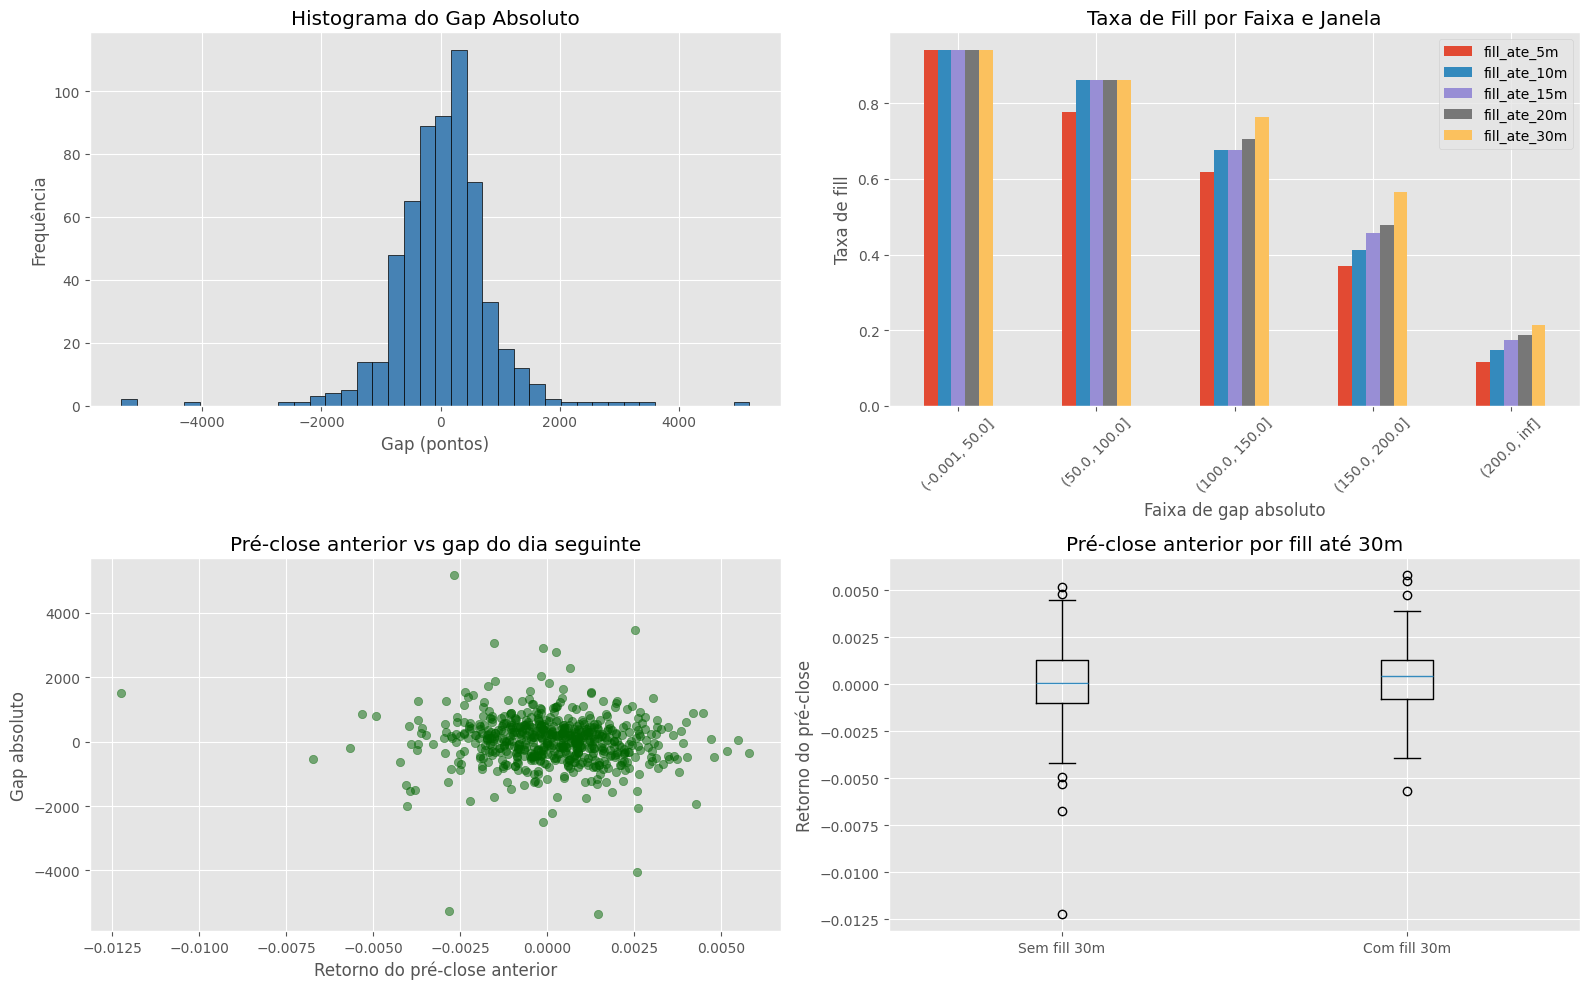

In [21]:
fig, eixos = plt.subplots(2, 2, figsize=(16, 10))

# Distribuição bruta dos gaps em pontos.
eixos[0, 0].hist(base_gap['gap_abs'].dropna(), bins=40, color='steelblue', edgecolor='black')
eixos[0, 0].set_title('Histograma do Gap Absoluto')
eixos[0, 0].set_xlabel('Gap (pontos)')
eixos[0, 0].set_ylabel('Frequência')

# Taxas de fill por faixa de gap, olhando apenas janelas intraday curtas.
taxas_temporais = (
    base_gap.groupby('abs_gap_bin')[['fill_ate_5m', 'fill_ate_10m', 'fill_ate_15m', 'fill_ate_20m', 'fill_ate_30m']]
    .mean()
)
taxas_temporais.plot(kind='bar', ax=eixos[0, 1])
eixos[0, 1].set_title('Taxa de Fill por Faixa e Janela')
eixos[0, 1].set_xlabel('Faixa de gap absoluto')
eixos[0, 1].set_ylabel('Taxa de fill')
eixos[0, 1].tick_params(axis='x', rotation=45)

# Relação entre o retorno do pré-close e o gap do dia seguinte.
eixos[1, 0].scatter(base_ml_valida['prev_preclose_return'], base_ml_valida['gap_abs'], alpha=0.5, color='darkgreen')
eixos[1, 0].set_title('Pré-close anterior vs gap do dia seguinte')
eixos[1, 0].set_xlabel('Retorno do pré-close anterior')
eixos[1, 0].set_ylabel('Gap absoluto')

# Compara o pré-close entre dias com fill até 30 minutos e sem fill até 30 minutos.
dados_boxplot = [
    base_ml_valida.loc[base_ml_valida['target_fill_30m'] == 0, 'prev_preclose_return'].dropna(),
    base_ml_valida.loc[base_ml_valida['target_fill_30m'] == 1, 'prev_preclose_return'].dropna()
]
eixos[1, 1].boxplot(dados_boxplot, tick_labels=['Sem fill 30m', 'Com fill 30m'])
eixos[1, 1].set_title('Pré-close anterior por fill até 30m')
eixos[1, 1].set_ylabel('Retorno do pré-close')

plt.tight_layout()
plt.show()


## 14. Modelagem mais robusta para os targets

Em vez de usar apenas uma regressão logística simples, vamos comparar modelos e ajustar o limiar de decisão.

Melhorias aplicadas:

- comparação entre regressão logística balanceada e random forest;
- divisão temporal em treino, validação e teste;
- escolha do melhor modelo com base na validação;
- ajuste do limiar de decisão para maximizar `F1` na validação;
- leitura de métricas mais adequadas para classes desbalanceadas.

Métricas principais:

- `accuracy`
- `balanced_accuracy`
- `ROC AUC`
- `average_precision`
- `F1`


In [22]:
# Lista de colunas candidatas para o modelo.
colunas_features = [
    'gap_abs',
    'gap_pct',
    'gap_atr',
    'abs_gap_abs',
    'gap_direction_num',
    'gap_sobre_range_anterior',
    'gap_sobre_atr_anterior',
    'gap_sobre_range_preclose',
    'prev_preclose_return',
    'prev_preclose_range',
    'prev_preclose_range_pct',
    'prev_preclose_volatility',
    'prev_preclose_volume',
    'prev_preclose_tick_volume',
    'prev_preclose_last_min_return',
    'prev_preclose_slope_points_per_min',
    'prev_preclose_close_position_day',
    'prev_preclose_close_position_window',
    'prev_preclose_day_return',
    'prev_preclose_day_range',
    'prev_daily_return_close_to_close',
    'prev_daily_return_open_to_close',
    'prev_daily_range',
    'prev_daily_atr_14',
    'prev_daily_atr_ratio',
    'prev_daily_close_position',
    'prev_daily_tick_volume',
    'prev_daily_n_bars',
    'volume_preclose_sobre_volume_dia_anterior',
    'intensidade_preclose',
    'sinal_preclose',
    'mesmo_sinal_gap_preclose',
    'distancia_fechamento_anterior_topo',
    'distancia_fechamento_anterior_fundo',
    'gap_x_preclose_return',
    'gap_x_preclose_volume',
    'gap_x_range_anterior',
]

alvos_modelo = [
    'target_gap_up',
    'target_fill_5m',
    'target_fill_10m',
    'target_fill_15m',
    'target_fill_20m',
    'target_fill_30m',
]

base_modelagem = base_ml[['session_date'] + colunas_features + alvos_modelo].copy()

# Split temporal em treino, validação e teste.
n_total = len(base_modelagem)
idx_treino = int(n_total * 0.6)
idx_validacao = int(n_total * 0.8)

base_treino = base_modelagem.iloc[:idx_treino].copy()
base_validacao = base_modelagem.iloc[idx_treino:idx_validacao].copy()
base_teste = base_modelagem.iloc[idx_validacao:].copy()

X_treino = base_treino[colunas_features]
X_validacao = base_validacao[colunas_features]
X_teste = base_teste[colunas_features]


def melhor_limiar_f1(y_real, probabilidade):
    precisao, recall, limiares = precision_recall_curve(y_real, probabilidade)
    f1 = 2 * precisao[:-1] * recall[:-1] / np.clip(precisao[:-1] + recall[:-1], 1e-9, None)
    if len(limiares) == 0:
        return 0.5, np.nan
    melhor_indice = int(np.nanargmax(f1))
    return float(limiares[melhor_indice]), float(f1[melhor_indice])


def avaliar_metricas(y_real, previsao, probabilidade):
    return {
        'accuracy': accuracy_score(y_real, previsao),
        'balanced_accuracy': balanced_accuracy_score(y_real, previsao),
        'f1': f1_score(y_real, previsao, zero_division=0),
        'roc_auc': roc_auc_score(y_real, probabilidade),
        'average_precision': average_precision_score(y_real, probabilidade),
    }


def construir_modelos():
    return {
        'logistica_balanceada': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
        ]),
        'random_forest_balanceada': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=8,
                class_weight='balanced_subsample',
                random_state=42,
                n_jobs=-1
            ))
        ]),
    }


def avaliar_alvo_binario(nome_alvo):
    y_treino = base_treino[nome_alvo]
    y_validacao = base_validacao[nome_alvo]
    y_teste = base_teste[nome_alvo]

    if len(base_treino) < MINIMO_LINHAS_TREINO or y_treino.nunique() < 2 or y_validacao.nunique() < 2 or y_teste.nunique() < 2:
        print(f'Base insuficiente para treinar {nome_alvo}.')
        return None

    melhor_resultado = None

    for nome_modelo, pipeline in construir_modelos().items():
        pipeline.fit(X_treino, y_treino)
        prob_validacao = pipeline.predict_proba(X_validacao)[:, 1]
        limiar, melhor_f1_valid = melhor_limiar_f1(y_validacao, prob_validacao)
        pred_validacao = (prob_validacao >= limiar).astype(int)
        metricas_validacao = avaliar_metricas(y_validacao, pred_validacao, prob_validacao)

        resultado_modelo = {
            'nome_modelo': nome_modelo,
            'pipeline': pipeline,
            'limiar': limiar,
            'f1_validacao_otimizado': melhor_f1_valid,
            'metricas_validacao': metricas_validacao,
        }

        if melhor_resultado is None or resultado_modelo['metricas_validacao']['f1'] > melhor_resultado['metricas_validacao']['f1']:
            melhor_resultado = resultado_modelo

    melhor_pipeline = melhor_resultado['pipeline']
    limiar_final = melhor_resultado['limiar']
    prob_teste = melhor_pipeline.predict_proba(X_teste)[:, 1]
    pred_teste = (prob_teste >= limiar_final).astype(int)
    metricas_teste = avaliar_metricas(y_teste, pred_teste, prob_teste)

    baseline_majoritaria = max(y_teste.mean(), 1 - y_teste.mean())

    print()
    print(f'Resultado para {nome_alvo}')
    print('Modelo escolhido:', melhor_resultado['nome_modelo'])
    print('Limiar escolhido:', round(limiar_final, 4))
    print('Accuracy:', round(metricas_teste['accuracy'], 4))
    print('Balanced Accuracy:', round(metricas_teste['balanced_accuracy'], 4))
    print('F1:', round(metricas_teste['f1'], 4))
    print('ROC AUC:', round(metricas_teste['roc_auc'], 4))
    print('Average Precision:', round(metricas_teste['average_precision'], 4))
    print('Baseline majoritária:', round(baseline_majoritaria, 4))
    print(classification_report(y_teste, pred_teste, digits=4))
    print('Matriz de confusão:')
    print(confusion_matrix(y_teste, pred_teste))

    model = melhor_pipeline.named_steps['model']
    if hasattr(model, 'coef_'):
        importancias = pd.Series(model.coef_[0], index=colunas_features).sort_values(key=np.abs, ascending=False)
    else:
        importancias = pd.Series(model.feature_importances_, index=colunas_features).sort_values(ascending=False)

    return {
        'nome_modelo': melhor_resultado['nome_modelo'],
        'pipeline': melhor_pipeline,
        'limiar': limiar_final,
        'metricas_teste': metricas_teste,
        'importancias': importancias,
    }


modelos = {}
for alvo in alvos_modelo:
    resultado = avaliar_alvo_binario(alvo)
    if resultado is not None:
        modelos[alvo] = resultado



Resultado para target_gap_up
Modelo escolhido: logistica_balanceada
Limiar escolhido: 0.9548
Accuracy: 0.9587
Balanced Accuracy: 0.9597
F1: 0.958
ROC AUC: 1.0
Average Precision: 1.0
Baseline majoritária: 0.5124
              precision    recall  f1-score   support

           0     0.9219    1.0000    0.9593        59
           1     1.0000    0.9194    0.9580        62

    accuracy                         0.9587       121
   macro avg     0.9609    0.9597    0.9587       121
weighted avg     0.9619    0.9587    0.9586       121

Matriz de confusão:
[[59  0]
 [ 5 57]]

Resultado para target_fill_5m
Modelo escolhido: random_forest_balanceada
Limiar escolhido: 0.5414
Accuracy: 0.8595
Balanced Accuracy: 0.8359
F1: 0.7671
ROC AUC: 0.9209
Average Precision: 0.8586
Baseline majoritária: 0.7025
              precision    recall  f1-score   support

           0     0.9048    0.8941    0.8994        85
           1     0.7568    0.7778    0.7671        36

    accuracy                      

## 15. Leitura das importâncias do melhor modelo

Nesta etapa mostramos as variáveis mais relevantes do melhor modelo selecionado para cada alvo.

Interpretação:

- regressão logística: valores maiores em módulo indicam maior peso no modelo;
- random forest: valores maiores indicam maior importância relativa na árvore.


In [23]:
for alvo, resultado in modelos.items():
    print()
    print(f'Top variáveis para {alvo}')
    print('Modelo:', resultado['nome_modelo'])
    print('Limiar:', round(resultado['limiar'], 4))
    print(resultado['importancias'].head(12).to_frame('importancia'))



Top variáveis para target_gap_up
Modelo: logistica_balanceada
Limiar: 0.9548
                          importancia
gap_direction_num            3.449773
gap_atr                      0.998724
gap_abs                      0.953826
gap_pct                      0.929005
mesmo_sinal_gap_preclose     0.455085
gap_sobre_atr_anterior       0.197198
gap_sobre_range_preclose     0.190363
sinal_preclose              -0.183378
gap_sobre_range_anterior     0.166412
intensidade_preclose         0.150495
prev_preclose_volatility     0.130948
abs_gap_abs                  0.127779

Top variáveis para target_fill_5m
Modelo: random_forest_balanceada
Limiar: 0.5414
                          importancia
abs_gap_abs                  0.138950
gap_sobre_range_anterior     0.117604
gap_sobre_atr_anterior       0.116914
gap_sobre_range_preclose     0.116243
gap_x_preclose_volume        0.098026
gap_x_range_anterior         0.052246
gap_atr                      0.051563
gap_pct                      0.043051
gap

## 16. Exportação das bases derivadas

No fim, salvamos as tabelas mais importantes para uso fora do notebook.

Arquivos exportados em pt-BR:

- base intraday limpa (`intraday_limpo`)
- base diária (`base_diaria`)
- base principal do gap (`base_gap`)
- base do pré-close (`base_preclose`)
- base integrada para machine learning (`base_ml`)
- resumo do gap por faixa (`resumo_gap_por_faixa`)
- tabela de eventos com alvos (`eventos_gap_alvos`)
- agenda diária do pregão (`agenda_diaria`)
- tabela de estatísticas (`tabela_estatisticas`)

Assim fica mais fácil estudar os resultados fora do notebook sem depender de reprocessar tudo a cada leitura.


In [24]:
# Exporta as principais tabelas para consulta fora do notebook.
exportacoes = {
    'intraday_limpo': base_intraday,
    'base_diaria': base_diaria.reset_index(),
    'base_gap': base_gap.reset_index(),
    'base_preclose': base_preclose.reset_index(),
    'base_ml': base_ml,
    'resumo_gap_por_faixa': resumo_gap_por_faixa,
    'eventos_gap_alvos': tabela_eventos,
    'agenda_diaria': agenda_diaria.reset_index(),
    'tabela_estatisticas': tabela_estatisticas.reset_index(),
}

for nome_arquivo, dataframe in exportacoes.items():
    caminho_csv = PASTA_SAIDA / f'{nome_arquivo}.csv'
    dataframe.to_csv(caminho_csv, index=False)

    caminho_parquet = PASTA_SAIDA / f'{nome_arquivo}.parquet'
    try:
        dataframe.to_parquet(caminho_parquet, index=False)
    except Exception as exc:
        print(f'Parquet não gerado para {nome_arquivo}: {exc}')


# Tabelas de apresentação do gap (geradas na seção 7).
tabela_gap_alta_apresentacao.to_csv(PASTA_SAIDA / 'tabela_gap_alta_apresentacao.csv', index=False)
tabela_gap_baixa_apresentacao.to_csv(PASTA_SAIDA / 'tabela_gap_baixa_apresentacao.csv', index=False)
tabela_unica_gap.to_csv(PASTA_SAIDA / 'tabela_unica_gap_apresentacao.csv', index=False)
tabela_overshoot_sem_gap.to_csv(PASTA_SAIDA / 'tabela_overshoot_sem_gap.csv', index=False)
contagem_gaps.to_csv(PASTA_SAIDA / 'contagem_gaps_resumo.csv', index=False)
print('Arquivos exportados em:', PASTA_SAIDA.resolve())


Parquet não gerado para base_gap: Unsupported cast from dictionary<values=extension<pandas.interval<ArrowIntervalType>>, indices=int8, ordered=1> to struct using function cast_struct
Parquet não gerado para base_ml: Unsupported cast from dictionary<values=extension<pandas.interval<ArrowIntervalType>>, indices=int8, ordered=1> to struct using function cast_struct
Parquet não gerado para resumo_gap_por_faixa: Unsupported cast from dictionary<values=extension<pandas.interval<ArrowIntervalType>>, indices=int8, ordered=1> to struct using function cast_struct
Arquivos exportados em: /content/outputs_gap_win


## 17. Próximos passos recomendados

Com a estrutura pronta, os próximos estudos naturais são:

1. testar janelas alternativas de fill, como 3, 5, 10, 15, 20, 30 e 60 minutos;
2. separar regimes por volatilidade, vencimento e horário de fechamento;
3. criar labels adicionais, como fill parcial até 10 minutos, reversão e tempo até máxima/mínima;
4. avaliar modelos mais fortes, como Random Forest, XGBoost e validação walk-forward;
5. incluir custos, slippage e regras operacionais para transformar a análise em pesquisa aplicada.

O notebook já deixa uma base consistente para essa evolução sem precisar refazer a preparação dos dados.


## 18. Gráfico de Candles por Dia

Gráfico intraday em estilo dark para os dias selecionados.

**Parâmetro `DIAS_FILTRO_CANDLE`** está na **seção 7** junto com os demais parâmetros.

- Se a lista estiver vazia, o gráfico usa automaticamente os **3 dias com maiores gaps em módulo**.
- Para escolher dias específicos, preencha a lista: `['2024-01-15', '2024-03-20']`.

A linha azul tracejada representa o **fechamento anterior** (nível de referência do gap).


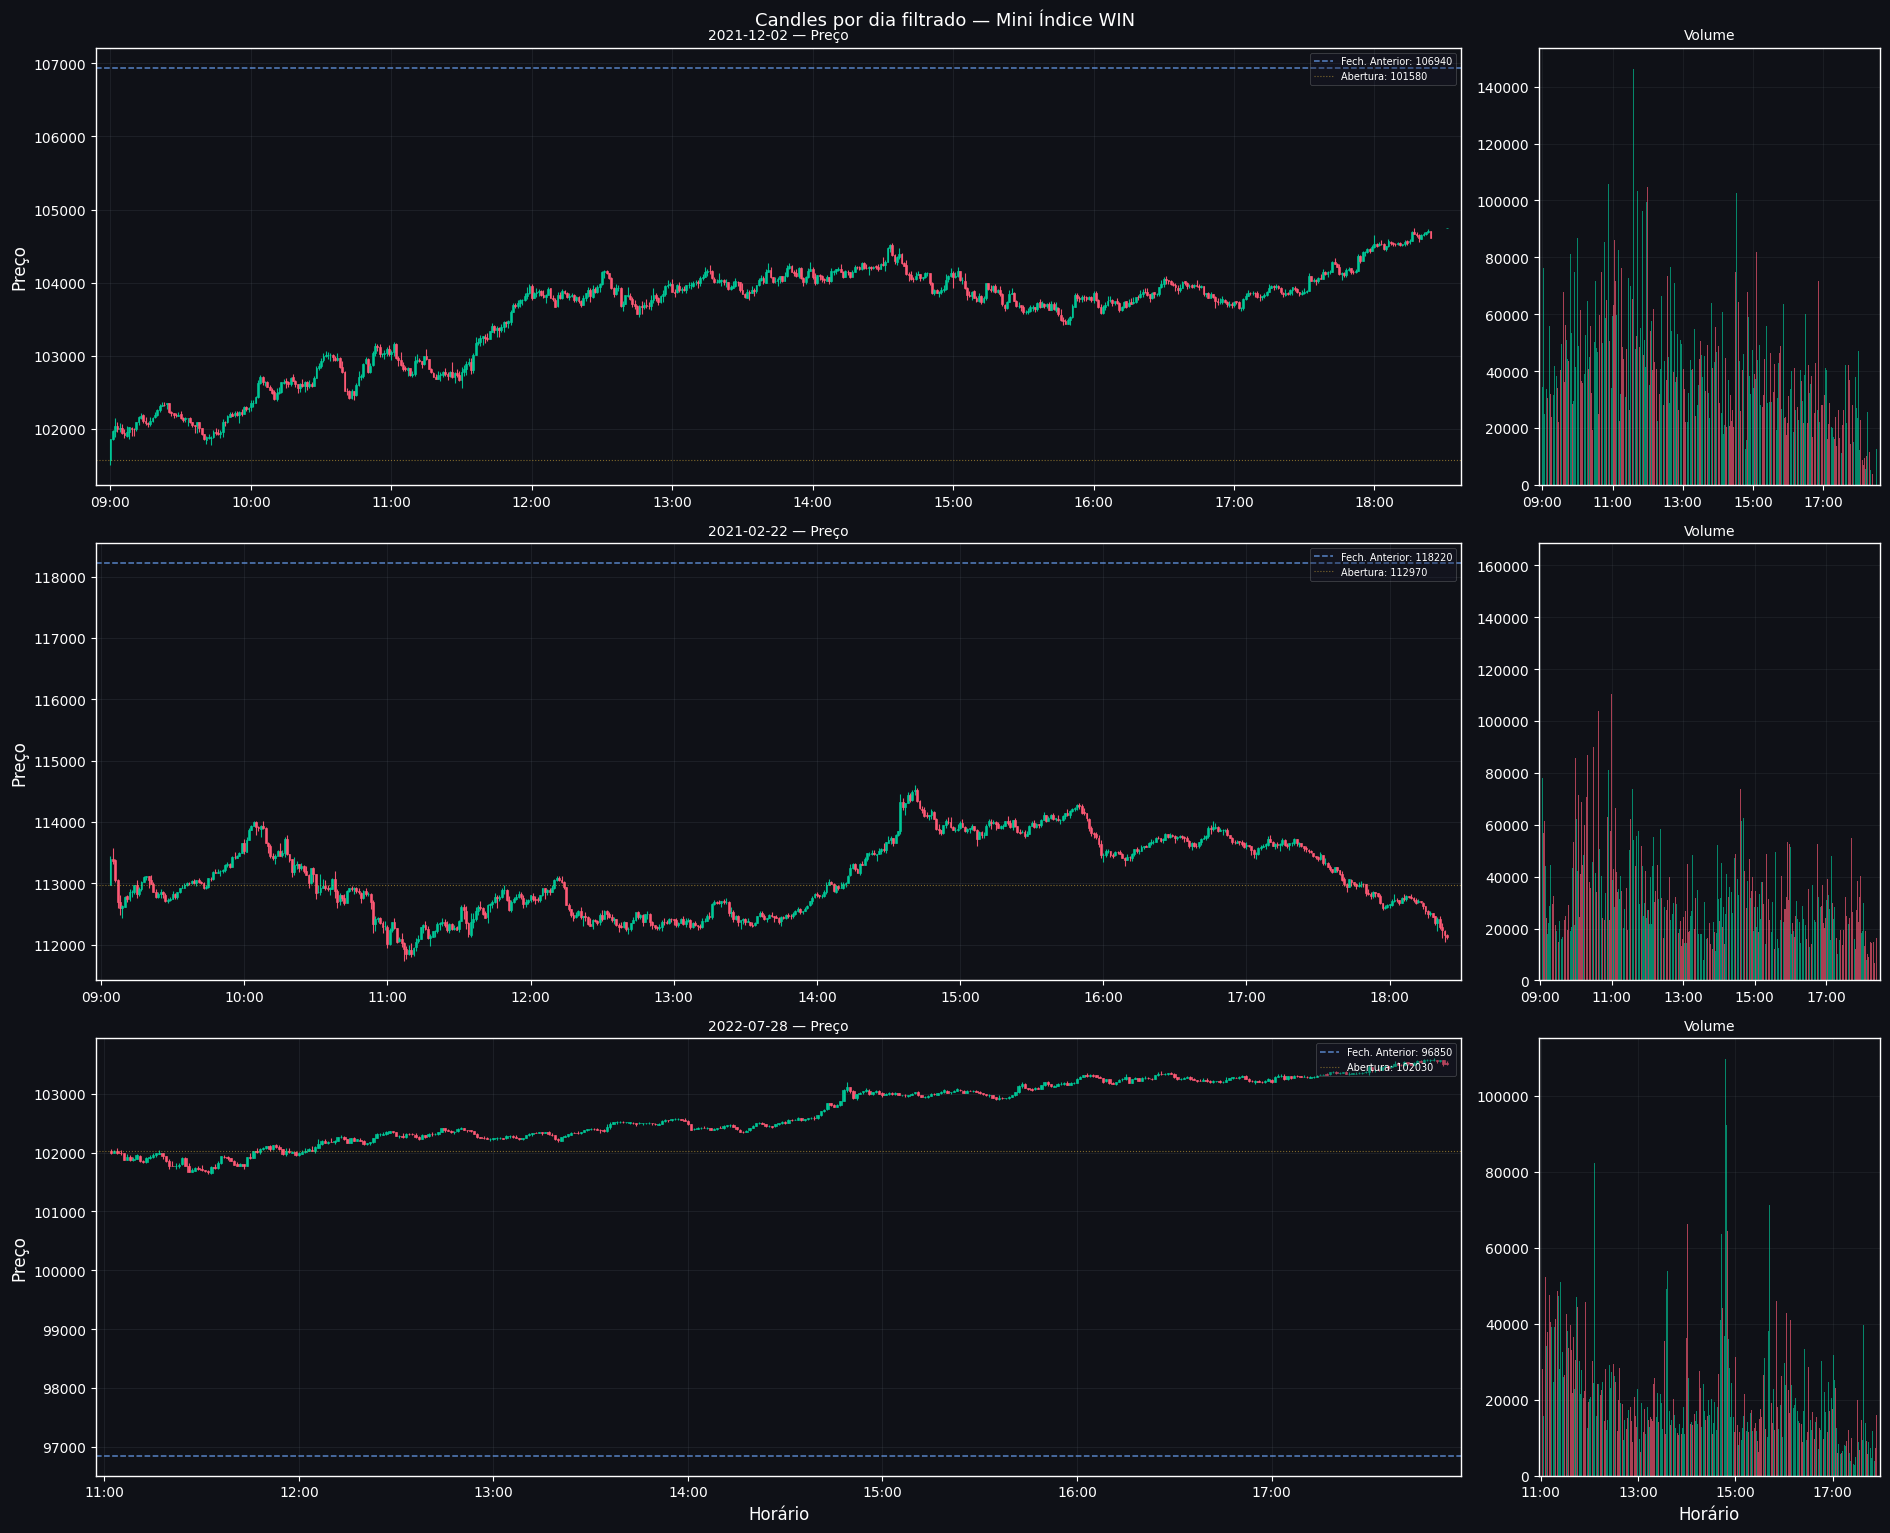

Dias no gráfico: ['2021-12-02', '2021-02-22', '2022-07-28']


In [25]:
import matplotlib.dates as mdates


def plotar_candles_filtrados(base_intraday_origem, base_gap_origem, dias_filtro, titulo='Candles intraday'):
    """
    Plota candles intraday com volume lateral em estilo dark.
    Inclui linha do fechamento anterior (referência do gap).
    """
    dias_filtro = [pd.to_datetime(d) for d in dias_filtro]
    blocos = []
    for dia in dias_filtro:
        bloco = (
            base_intraday_origem.loc[base_intraday_origem['session_date'] == dia]
            .sort_values('datetime')
            .reset_index(drop=True)
            .copy()
        )
        if not bloco.empty:
            blocos.append((dia, bloco))

    if not blocos:
        print('Nenhum dia com dados encontrado para o filtro informado.')
        return

    n = len(blocos)
    fig, axes = plt.subplots(n, 2, figsize=(19, 5.2 * n), gridspec_kw={'width_ratios': [8, 2]})
    if n == 1:
        axes = np.array([axes])

    fig.patch.set_facecolor('#0f1117')
    volume_col = 'volume' if 'volume' in base_intraday_origem.columns else 'tick_volume'

    for row, (dia, bloco) in enumerate(blocos):
        ax = axes[row, 0]
        axv = axes[row, 1]

        bloco['x'] = mdates.date2num(bloco['datetime'])
        width = (1 / (24 * 60)) * 0.78

        ax.set_facecolor('#0f1117')
        axv.set_facecolor('#0f1117')

        for _, linha in bloco.iterrows():
            cor = '#00c897' if linha['close'] >= linha['open'] else '#ff5a76'
            ax.vlines(linha['x'], linha['low'], linha['high'], color=cor, linewidth=0.8, alpha=0.95)
            corpo_min = min(linha['open'], linha['close'])
            corpo_altura = max(abs(linha['close'] - linha['open']), 0.7)
            candle = plt.Rectangle(
                (linha['x'] - width / 2, corpo_min), width, corpo_altura,
                facecolor=cor, edgecolor=cor, alpha=0.92
            )
            ax.add_patch(candle)
            axv.bar(linha['x'], linha.get(volume_col, np.nan), width=width, color=cor, alpha=0.65)

        # Linha do fechamento anterior (referência do gap)
        abertura_dia = bloco['open'].iloc[0]
        if base_gap_origem is not None and dia in base_gap_origem.index:
            prev_close = base_gap_origem.loc[dia, 'prev_close']
            ax.axhline(prev_close, color='#6ea8fe', linewidth=1.1, alpha=0.75, linestyle='--',
                       label=f'Fech. Anterior: {prev_close:.0f}')
            ax.axhline(abertura_dia, color='#f0c040', linewidth=0.8, alpha=0.5, linestyle=':',
                       label=f'Abertura: {abertura_dia:.0f}')
            ax.legend(loc='upper right', fontsize=7, framealpha=0.3,
                      labelcolor='white', facecolor='#1a1a2e')

        ax.set_title(f"{dia.strftime('%Y-%m-%d')} — Preço", color='white', fontsize=10)
        ax.set_ylabel('Preço', color='white')
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')
        ax.grid(alpha=0.15, color='#6c757d')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

        axv.set_title('Volume', color='white', fontsize=10)
        axv.tick_params(axis='x', colors='white')
        axv.tick_params(axis='y', colors='white')
        axv.grid(alpha=0.12, color='#6c757d')
        axv.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axv.xaxis.set_major_locator(mdates.HourLocator(interval=2))

    plt.setp(axes[:, 0], xmargin=0.01)
    plt.setp(axes[:, 1], xmargin=0.01)
    axes[-1, 0].set_xlabel('Horário', color='white')
    axes[-1, 1].set_xlabel('Horário', color='white')
    fig.suptitle(titulo, fontsize=13, color='white')
    fig.tight_layout()
    plt.show()


if not DIAS_FILTRO_CANDLE:
    dias_candle = (
        tabela_unica_gap
        .assign(gap_mod=tabela_unica_gap['Gap Módulo (pts)'])
        .sort_values('gap_mod', ascending=False)
        .head(3)['Data']
        .tolist()
    )
else:
    dias_candle = [pd.to_datetime(d).strftime('%Y-%m-%d') for d in DIAS_FILTRO_CANDLE]

plotar_candles_filtrados(
    base_intraday_origem=base_intraday,
    base_gap_origem=base_gap,
    dias_filtro=dias_candle,
    titulo='Candles por dia filtrado — Mini Índice WIN'
)
print('Dias no gráfico:', [pd.to_datetime(d).strftime('%Y-%m-%d') for d in dias_candle])
